# Dissertation Title : Evaluating Machine Learning and Deep Learning Models for Employee Attrition Prediction with Hyperparameter Tuning

# Mounting to the Drive

In [1]:
# I imported the drive module from google.colab to access Google Drive.
from google.colab import drive

# I mounted my Google Drive to the '/content/drive' directory
# so that I could access my files directly within the Colab environment.
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Data Loading, Dataset Overview, and Initial Data Exploration

In [2]:
# I imported the required libraries to load and analyse the dataset.
import pandas as pd
import numpy as np

# I loaded the training and testing datasets.
train_df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/train.csv')
test_df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/test.csv')

# I displayed the first five records to verify that the dataset was loaded successfully.
display(train_df.head())

# I checked the number of observations and variables in both datasets.
print("Training Dataset Shape:", train_df.shape)
print("Testing Dataset Shape:", test_df.shape)

# I displayed the names of all variables in the training dataset.
print("\nFeature Names:")
print(train_df.columns.tolist())

# I identified the target variable and independent variables.
target_variable = "Attrition"   # Change this if your target column name is different.
independent_variables = [col for col in train_df.columns if col != target_variable]

print("\nTarget Variable:")
print(target_variable)

print("\nIndependent Variables:")
print(independent_variables)

print("\nNumber of Independent Variables:", len(independent_variables))

# I examined the data types and overall structure of the dataset.
print("\nDataset Information:")
train_df.info()

# I generated summary statistics to understand the distribution of the variables.
print("\nSummary Statistics:")
display(train_df.describe(include="all").T)

,Employee ID,Age,Gender,Years at Company,Job Role,Monthly Income,Work-Life Balance,Job Satisfaction,Performance Rating,Number of Promotions,...,Number of Dependents,Job Level,Company Size,Company Tenure,Remote Work,Leadership Opportunities,Innovation Opportunities,Company Reputation,Employee Recognition,Attrition
0,8410,31,Male,19,Education,5390,Excellent,Medium,Average,2,...,0,Mid,Medium,89,No,No,No,Excellent,Medium,Stayed
1,64756,59,Female,4,Media,5534,Poor,High,Low,3,...,3,Mid,Medium,21,No,No,No,Fair,Low,Stayed
2,30257,24,Female,10,Healthcare,8159,Good,High,Low,0,...,3,Mid,Medium,74,No,No,No,Poor,Low,Stayed
3,65791,36,Female,7,Education,3989,Good,High,High,1,...,2,Mid,Small,50,Yes,No,No,Good,Medium,Stayed
4,65026,56,Male,41,Education,4821,Fair,Very High,Average,0,...,0,Senior,Medium,68,No,No,No,Fair,Medium,Stayed


Training Dataset Shape: (59598, 24)
Testing Dataset Shape: (14900, 24)

Feature Names:
['Employee ID', 'Age', 'Gender', 'Years at Company', 'Job Role', 'Monthly Income', 'Work-Life Balance', 'Job Satisfaction', 'Performance Rating', 'Number of Promotions', 'Overtime', 'Distance from Home', 'Education Level', 'Marital Status', 'Number of Dependents', 'Job Level', 'Company Size', 'Company Tenure', 'Remote Work', 'Leadership Opportunities', 'Innovation Opportunities', 'Company Reputation', 'Employee Recognition', 'Attrition']

Target Variable:
Attrition

Independent Variables:
['Employee ID', 'Age', 'Gender', 'Years at Company', 'Job Role', 'Monthly Income', 'Work-Life Balance', 'Job Satisfaction', 'Performance Rating', 'Number of Promotions', 'Overtime', 'Distance from Home', 'Education Level', 'Marital Status', 'Number of Dependents', 'Job Level', 'Company Size', 'Company Tenure', 'Remote Work', 'Leadership Opportunities', 'Innovation Opportunities', 'Company Reputation', 'Employee Reco

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Employee ID,59598.0,NaN,NaN,NaN,37227.118729,21519.150028,1.0,18580.25,37209.5,55876.75,74498.0
Age,59598.0,NaN,NaN,NaN,38.565875,12.079673,18.0,28.0,39.0,49.0,59.0
Gender,59598,2,Male,32739,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Years at Company,59598.0,NaN,NaN,NaN,15.753901,11.245981,1.0,7.0,13.0,23.0,51.0
Job Role,59598,5,Technology,15507,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Monthly Income,59598.0,NaN,NaN,NaN,7302.397983,2151.457423,1316.0,5658.0,7354.0,8880.0,16149.0
Work-Life Balance,59598,4,Good,22528,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Job Satisfaction,59598,4,High,29779,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Performance Rating,59598,4,Average,35810,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Number of Promotions,59598.0,NaN,NaN,NaN,0.832578,0.994991,0.0,0.0,1.0,2.0,4.0


# Data Pre Processing

# Data Quality Assessment and Categorical Variable Analysis

In [3]:
# I displayed the original column names in the dataset.
print("Original Columns:")
print(train_df.columns.tolist())

# I created a list containing the columns that should be removed.
# Employee ID is an identifier, while Gender and Marital Status are
# sensitive demographic attributes removed based on ethical considerations.
columns_to_remove = ["Employee ID", "Gender", "Marital Status"]

# I removed the selected columns from the dataset.
train_df = train_df.drop(columns=columns_to_remove)

# I displayed the remaining columns after removing the unnecessary features.
print("\nColumns After Removing Sensitive Features:")
print(train_df.columns.tolist())

# I checked the dataset for missing values.
print("\nMissing Values:")

# I calculated the number of missing values in each column.
missing_values = train_df.isnull().sum()

# I displayed only the columns that contain missing values.
missing_values = missing_values[missing_values > 0]

# I checked whether any missing values exist in the dataset.
if len(missing_values) > 0:
    print(missing_values)
else:
    print("No missing values found.")

# I checked the dataset for duplicate records.
duplicate_count = train_df.duplicated().sum()

# I displayed the total number of duplicate records.
print("\nDuplicate Records:")
print(duplicate_count)

# I identified all categorical variables in the dataset.
categorical_columns = train_df.select_dtypes(include=["object"]).columns

# I displayed the names of the categorical variables.
print("\nCategorical Variables:")
print(list(categorical_columns))

# I displayed the unique values for each categorical variable.
print("\nUnique Values in Categorical Variables:")

# I iterated through each categorical column.
for column in categorical_columns:

    # I displayed the name of the categorical variable.
    print(f"\n{column}:")

    # I displayed all unique values in the current categorical variable.
    print(train_df[column].unique())

    # I displayed the total number of unique values.
    print("Number of Unique Values:", train_df[column].nunique())

# I identified all numerical variables in the dataset.
numerical_columns = train_df.select_dtypes(include=["int64", "float64"]).columns

# I displayed the names of the numerical variables.
print("\nNumerical Variables:")
print(list(numerical_columns))

# I displayed the summary statistics for all numerical variables.
print("\nSummary Statistics:")
print(train_df.describe())

# I displayed the shape of the dataset.
print("\nDataset Shape:")
print(train_df.shape)

# I displayed the total number of rows in the dataset.
print("\nNumber of Rows:")
print(train_df.shape[0])

# I displayed the total number of columns in the dataset.
print("\nNumber of Columns:")
print(train_df.shape[1])

# I displayed the data type of every column in the dataset.
print("\nData Types:")
print(train_df.dtypes)

Original Columns:
['Employee ID', 'Age', 'Gender', 'Years at Company', 'Job Role', 'Monthly Income', 'Work-Life Balance', 'Job Satisfaction', 'Performance Rating', 'Number of Promotions', 'Overtime', 'Distance from Home', 'Education Level', 'Marital Status', 'Number of Dependents', 'Job Level', 'Company Size', 'Company Tenure', 'Remote Work', 'Leadership Opportunities', 'Innovation Opportunities', 'Company Reputation', 'Employee Recognition', 'Attrition']

Columns After Removing Sensitive Features:
['Age', 'Years at Company', 'Job Role', 'Monthly Income', 'Work-Life Balance', 'Job Satisfaction', 'Performance Rating', 'Number of Promotions', 'Overtime', 'Distance from Home', 'Education Level', 'Number of Dependents', 'Job Level', 'Company Size', 'Company Tenure', 'Remote Work', 'Leadership Opportunities', 'Innovation Opportunities', 'Company Reputation', 'Employee Recognition', 'Attrition']

Missing Values:
No missing values found.

Duplicate Records:
0

Categorical Variables:
['Job Rol

# Categorical Variable Encoding and Data Transformation

In [4]:
# I encoded the binary categorical variables using mapping.
train_df["Overtime"] = train_df["Overtime"].map({"Yes": 1, "No": 0})
train_df["Remote Work"] = train_df["Remote Work"].map({"Yes": 1, "No": 0})
train_df["Leadership Opportunities"] = train_df["Leadership Opportunities"].map({"Yes": 1, "No": 0})
train_df["Innovation Opportunities"] = train_df["Innovation Opportunities"].map({"Yes": 1, "No": 0})
train_df["Attrition"] = train_df["Attrition"].map({"Stayed": 0, "Left": 1})

# I encoded the binary categorical variables in the testing dataset.
test_df["Overtime"] = test_df["Overtime"].map({"Yes": 1, "No": 0})
test_df["Remote Work"] = test_df["Remote Work"].map({"Yes": 1, "No": 0})
test_df["Leadership Opportunities"] = test_df["Leadership Opportunities"].map({"Yes": 1, "No": 0})
test_df["Innovation Opportunities"] = test_df["Innovation Opportunities"].map({"Yes": 1, "No": 0})

# I created mapping dictionaries for the ordinal categorical variables.
ordinal_mapping = {
    "Work-Life Balance": {
        "Poor": 1,
        "Fair": 2,
        "Good": 3,
        "Excellent": 4
    },
    "Job Satisfaction": {
        "Low": 1,
        "Medium": 2,
        "High": 3,
        "Very High": 4
    },
    "Performance Rating": {
        "Low": 1,
        "Below Average": 2,
        "Average": 3,
        "High": 4
    },
    "Education Level": {
        "High School": 1,
        "Associate Degree": 2,
        "Bachelor’s Degree": 3,
        "Master’s Degree": 4,
        "PhD": 5
    },
    "Job Level": {
        "Entry": 1,
        "Mid": 2,
        "Senior": 3
    },
    "Company Size": {
        "Small": 1,
        "Medium": 2,
        "Large": 3
    },
    "Company Reputation": {
        "Poor": 1,
        "Fair": 2,
        "Good": 3,
        "Excellent": 4
    },
    "Employee Recognition": {
        "Low": 1,
        "Medium": 2,
        "High": 3,
        "Very High": 4
    }
}

# I encoded the ordinal categorical variables in both datasets.
for column, mapping in ordinal_mapping.items():
    train_df[column] = train_df[column].map(mapping)
    test_df[column] = test_df[column].map(mapping)

# I identified the nominal categorical variables that require one-hot encoding.
nominal_columns = ["Job Role"]

# I applied one-hot encoding to the training dataset.
train_df = pd.get_dummies(
    train_df,
    columns=nominal_columns,
    drop_first=True,
    dtype=int
)

# I applied one-hot encoding to the testing dataset.
test_df = pd.get_dummies(
    test_df,
    columns=nominal_columns,
    drop_first=True,
    dtype=int
)

# I aligned the testing dataset with the training dataset to ensure both datasets have identical columns.
train_df, test_df = train_df.align(test_df, join="left", axis=1, fill_value=0)

# I displayed any remaining categorical variables after encoding.
print("Remaining Categorical Variables:")
print(train_df.select_dtypes(include="object").columns.tolist())

# I displayed the shape of the training dataset after encoding.
print("\nTraining Dataset Shape:")
print(train_df.shape)

# I displayed the shape of the testing dataset after encoding.
print("\nTesting Dataset Shape:")
print(test_df.shape)

# I displayed the first five rows of the encoded training dataset.
display(train_df.head())

Remaining Categorical Variables:
[]

Training Dataset Shape:
(59598, 24)

Testing Dataset Shape:
(14900, 24)


,Age,Years at Company,Monthly Income,Work-Life Balance,Job Satisfaction,Performance Rating,Number of Promotions,Overtime,Distance from Home,Education Level,...,Remote Work,Leadership Opportunities,Innovation Opportunities,Company Reputation,Employee Recognition,Attrition,Job Role_Finance,Job Role_Healthcare,Job Role_Media,Job Role_Technology
0,31,19,5390,4,2,3,2,0,22,2,...,0,0,0,4,2,0,0,0,0,0
1,59,4,5534,1,3,1,3,0,21,4,...,0,0,0,2,1,0,0,0,1,0
2,24,10,8159,3,3,1,0,0,11,3,...,0,0,0,1,1,0,0,1,0,0
3,36,7,3989,3,3,4,1,0,27,1,...,1,0,0,3,2,0,0,0,0,0
4,56,41,4821,2,4,3,0,1,71,1,...,0,0,0,2,2,0,0,0,0,0


# Exploratory Data Analysis

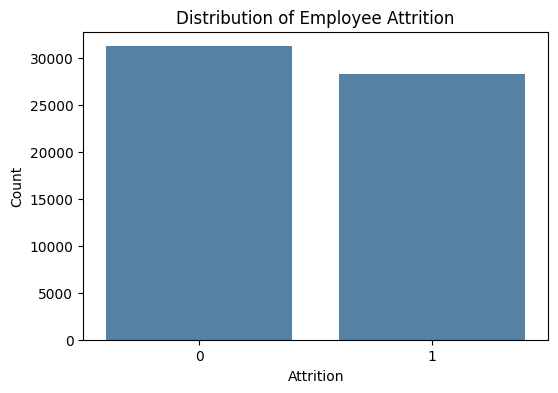

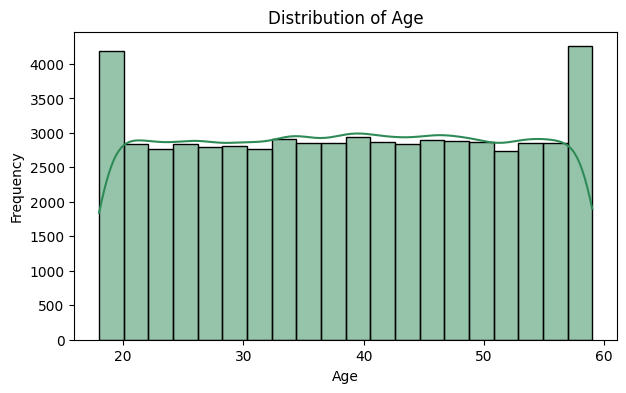

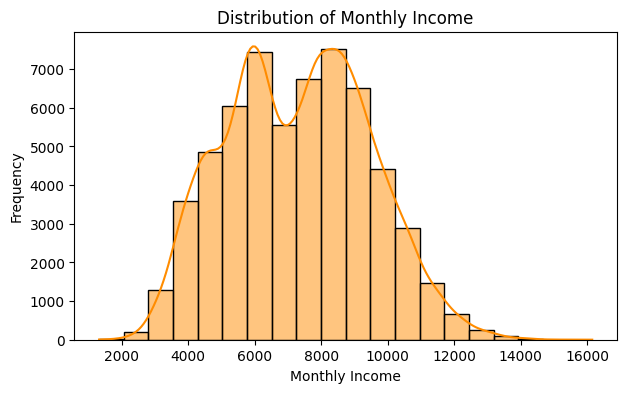

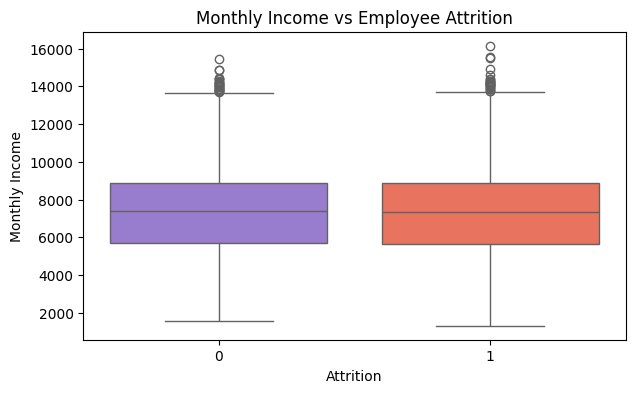

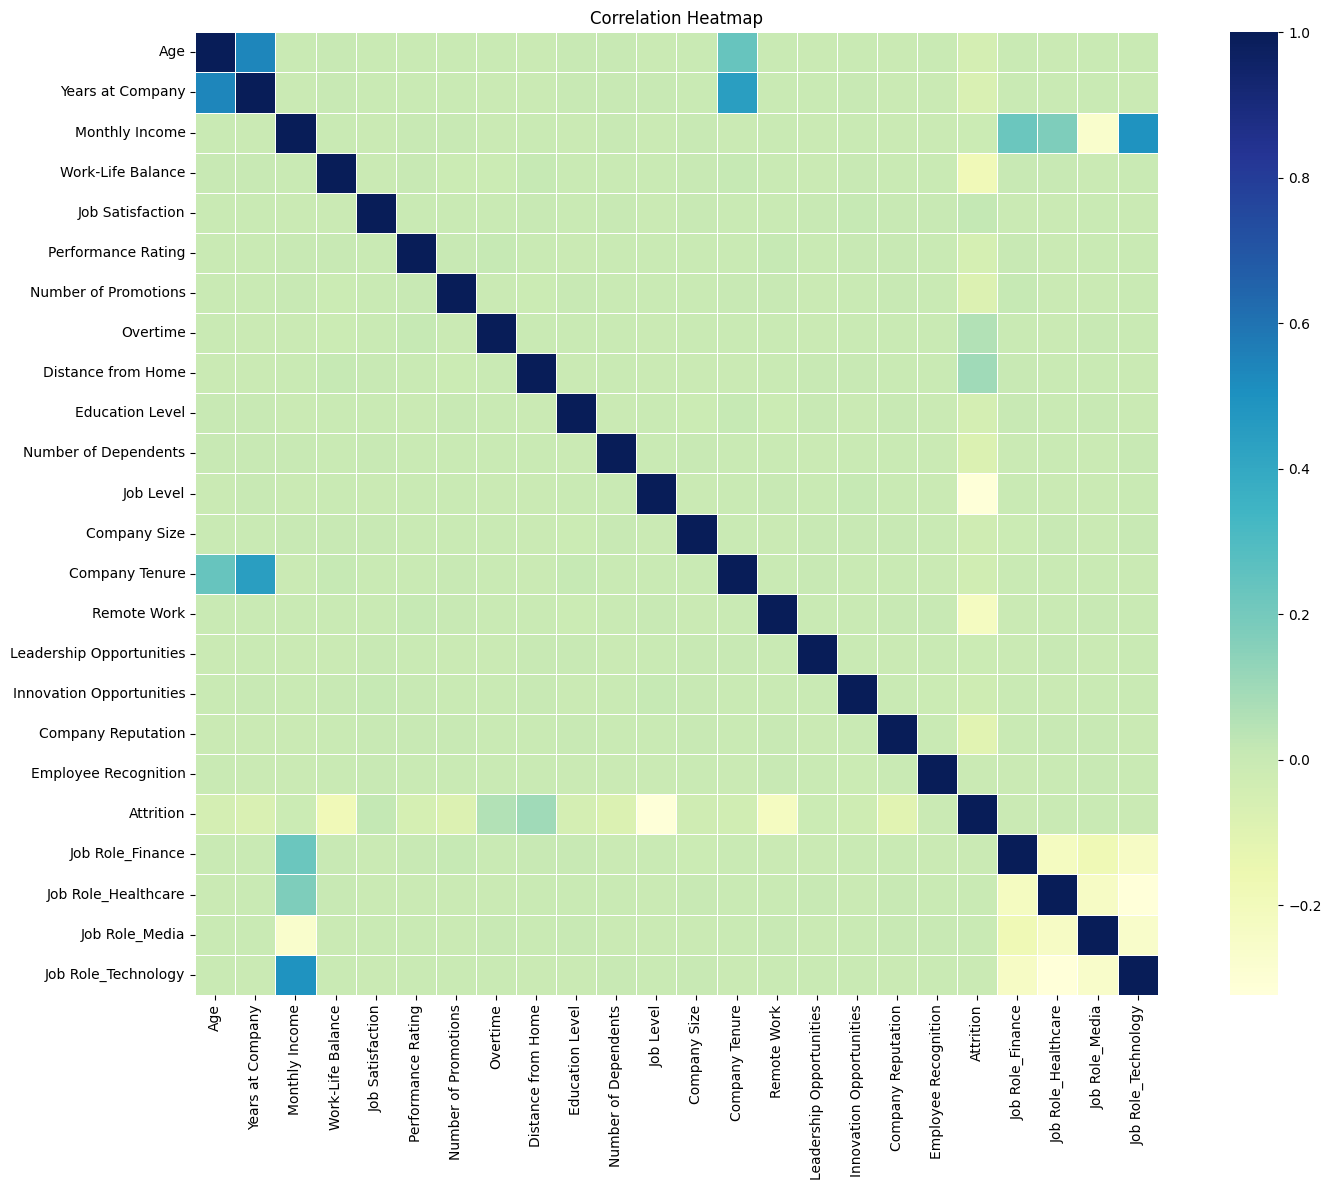

In [5]:
# I imported the required libraries for exploratory data analysis.
import matplotlib.pyplot as plt
import seaborn as sns

# I created a copy of the dataset for exploratory data analysis.
eda_df = train_df.copy()



# I analysed the distribution of the target variable.
plt.figure(figsize=(6,4))
sns.countplot(x="Attrition", data=eda_df, color="steelblue")
plt.title("Distribution of Employee Attrition")
plt.xlabel("Attrition")
plt.ylabel("Count")
plt.show()

# I examined the distribution of employee age.
plt.figure(figsize=(7,4))
sns.histplot(eda_df["Age"], bins=20, kde=True, color="seagreen")
plt.title("Distribution of Age")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

# I examined the distribution of monthly income.
plt.figure(figsize=(7,4))
sns.histplot(eda_df["Monthly Income"], bins=20, kde=True, color="darkorange")
plt.title("Distribution of Monthly Income")
plt.xlabel("Monthly Income")
plt.ylabel("Frequency")
plt.show()

# I analysed the relationship between monthly income and employee attrition.
plt.figure(figsize=(7,4))
sns.boxplot(
    x="Attrition",
    y="Monthly Income",
    hue="Attrition",
    data=eda_df,
    palette=["mediumpurple", "tomato"],
    legend=False
)
plt.title("Monthly Income vs Employee Attrition")
plt.xlabel("Attrition")
plt.ylabel("Monthly Income")
plt.show()

# I examined the relationships among the variables using a correlation heatmap.
plt.figure(figsize=(16,12))
sns.heatmap(
    eda_df.corr(),
    cmap="YlGnBu",
    annot=False,
    linewidths=0.5,
    square=True
)
plt.title("Correlation Heatmap")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Splitting the Dataset

In [6]:
# I imported the required function for splitting the dataset.
from sklearn.model_selection import train_test_split

# I separated the independent variables and target variable.
X = train_df.drop(columns=["Attrition"])
y = train_df["Attrition"]

# I split the dataset into training and validation sets.
X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# I displayed the shape of each dataset.
print("Training Features Shape:", X_train.shape)
print("Validation Features Shape:", X_valid.shape)

print("\nTraining Labels Shape:", y_train.shape)
print("Validation Labels Shape:", y_valid.shape)

# I displayed the class distribution after splitting.
print("\nTraining Class Distribution:")
print(y_train.value_counts())

print("\nValidation Class Distribution:")
print(y_valid.value_counts())

Training Features Shape: (47678, 23)
Validation Features Shape: (11920, 23)

Training Labels Shape: (47678,)
Validation Labels Shape: (11920,)

Training Class Distribution:
Attrition
0    25008
1    22670
Name: count, dtype: int64

Validation Class Distribution:
Attrition
0    6252
1    5668
Name: count, dtype: int64


# Class Imbalance Using SMOTE

Class Distribution Before SMOTE:
Attrition
0    25008
1    22670
Name: count, dtype: int64

Percentage Distribution Before SMOTE:
Attrition
0    52.45
1    47.55
Name: proportion, dtype: float64


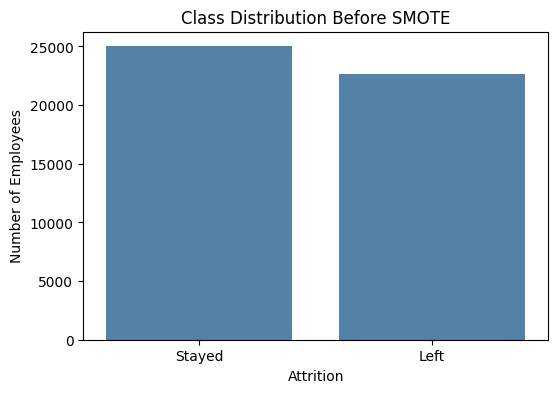

Training Features Shape After SMOTE: (50016, 23)
Training Labels Shape After SMOTE: (50016,)

Class Distribution After SMOTE:
Attrition
0    25008
1    25008
Name: count, dtype: int64

Percentage Distribution After SMOTE:
Attrition
0    50.0
1    50.0
Name: proportion, dtype: float64


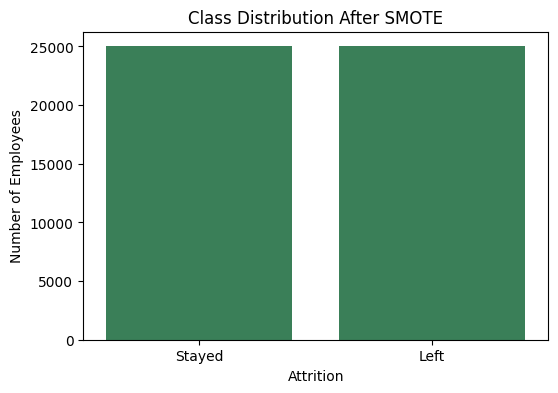

In [7]:
# I imported the required libraries for handling class imbalance.
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import seaborn as sns

# I displayed the class distribution before applying SMOTE.
print("Class Distribution Before SMOTE:")
print(y_train.value_counts())

print("\nPercentage Distribution Before SMOTE:")
print((y_train.value_counts(normalize=True) * 100).round(2))

# I visualised the class distribution before applying SMOTE.
plt.figure(figsize=(6,4))
sns.countplot(x=y_train, color="steelblue")

plt.title("Class Distribution Before SMOTE")
plt.xlabel("Attrition")
plt.ylabel("Number of Employees")
plt.xticks([0, 1], ["Stayed", "Left"])

plt.show()

# I created the SMOTE object.
smote = SMOTE(random_state=42)

# I balanced the training dataset using SMOTE.
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# I displayed the dataset shapes after applying SMOTE.
print("Training Features Shape After SMOTE:", X_train_smote.shape)
print("Training Labels Shape After SMOTE:", y_train_smote.shape)

# I displayed the class distribution after applying SMOTE.
print("\nClass Distribution After SMOTE:")
print(y_train_smote.value_counts())

print("\nPercentage Distribution After SMOTE:")
print((y_train_smote.value_counts(normalize=True) * 100).round(2))

# I visualised the balanced class distribution after applying SMOTE.
plt.figure(figsize=(6,4))
sns.countplot(x=y_train_smote, color="seagreen")

plt.title("Class Distribution After SMOTE")
plt.xlabel("Attrition")
plt.ylabel("Number of Employees")
plt.xticks([0, 1], ["Stayed", "Left"])

plt.show()

# Training and Evaluating the Models

# Default Models

# Model 1 : Logistic Regression

Logistic Regression Performance

Accuracy: 0.7049
Precision: 0.6838
Recall: 0.7057
F1-Score: 0.6946

Efficiency Metrics
Training Time (seconds): 0.073777
Testing Time (seconds): 0.000859
Training Complexity: O(n × d)
Prediction Complexity: O(d)

Classification Report
              precision    recall  f1-score   support

           0       0.73      0.70      0.71      6252
           1       0.68      0.71      0.69      5668

    accuracy                           0.70     11920
   macro avg       0.70      0.70      0.70     11920
weighted avg       0.71      0.70      0.71     11920

Confusion Matrix
[[4402 1850]
 [1668 4000]]


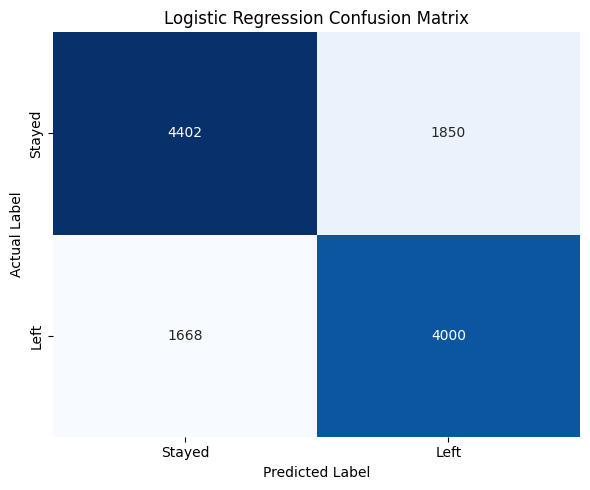


Stored Logistic Regression Results
Model: Logistic Regression
Accuracy: 0.7048657718120805
Precision: 0.6837606837606838
Recall: 0.7057163020465773
F1-Score: 0.6945650286508074
Training Time (s): 0.073777175000032
Testing Time (s): 0.0008588009995946777
Training Complexity: O(n × d)
Prediction Complexity: O(d)
Classification Report:               precision    recall  f1-score   support

           0       0.73      0.70      0.71      6252
           1       0.68      0.71      0.69      5668

    accuracy                           0.70     11920
   macro avg       0.70      0.70      0.70     11920
weighted avg       0.71      0.70      0.71     11920

Confusion Matrix: [[4402 1850]
 [1668 4000]]


In [8]:
# I imported the required libraries.
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import matplotlib.pyplot as plt
import seaborn as sns
import time

# I created the standard scaler.
scaler = StandardScaler()

# I standardised the training and validation datasets.
X_train_smote_scaled = scaler.fit_transform(X_train_smote)
X_valid_scaled = scaler.transform(X_valid)

# I recorded the model training start time.
lr_train_start_time = time.perf_counter()

# I created the Logistic Regression model.
logistic_regression_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

# I trained the Logistic Regression model.
logistic_regression_model.fit(
    X_train_smote_scaled,
    y_train_smote
)

# I calculated the model training time.
lr_training_time = time.perf_counter() - lr_train_start_time

# I recorded the prediction start time.
lr_test_start_time = time.perf_counter()

# I predicted the employee attrition for the validation dataset.
lr_predictions = logistic_regression_model.predict(
    X_valid_scaled
)

# I calculated the model prediction time.
lr_testing_time = time.perf_counter() - lr_test_start_time

# I calculated the evaluation metrics.
lr_accuracy = accuracy_score(y_valid, lr_predictions)
lr_precision = precision_score(y_valid, lr_predictions)
lr_recall = recall_score(y_valid, lr_predictions)
lr_f1_score = f1_score(y_valid, lr_predictions)

# I generated the classification report.
lr_classification_report = classification_report(
    y_valid,
    lr_predictions
)

# I generated the confusion matrix.
lr_confusion_matrix = confusion_matrix(
    y_valid,
    lr_predictions
)

# I stored the algorithm complexity.
lr_training_complexity = "O(n × d)"
lr_prediction_complexity = "O(d)"

# I displayed the evaluation metrics.
print("Logistic Regression Performance")

print(f"\nAccuracy: {lr_accuracy:.4f}")
print(f"Precision: {lr_precision:.4f}")
print(f"Recall: {lr_recall:.4f}")
print(f"F1-Score: {lr_f1_score:.4f}")

print("\nEfficiency Metrics")
print(f"Training Time (seconds): {lr_training_time:.6f}")
print(f"Testing Time (seconds): {lr_testing_time:.6f}")
print(f"Training Complexity: {lr_training_complexity}")
print(f"Prediction Complexity: {lr_prediction_complexity}")

print("\nClassification Report")
print(lr_classification_report)

print("Confusion Matrix")
print(lr_confusion_matrix)

# I visualised the confusion matrix.
plt.figure(figsize=(6,5))

sns.heatmap(
    lr_confusion_matrix,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    xticklabels=["Stayed", "Left"],
    yticklabels=["Stayed", "Left"]
)

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.tight_layout()
plt.show()

# I stored the evaluation results for future comparison.
lr_results = {
    "Model": "Logistic Regression",
    "Accuracy": lr_accuracy,
    "Precision": lr_precision,
    "Recall": lr_recall,
    "F1-Score": lr_f1_score,
    "Training Time (s)": lr_training_time,
    "Testing Time (s)": lr_testing_time,
    "Training Complexity": lr_training_complexity,
    "Prediction Complexity": lr_prediction_complexity,
    "Classification Report": lr_classification_report,
    "Confusion Matrix": lr_confusion_matrix
}

# I displayed the stored evaluation results.
print("\nStored Logistic Regression Results")

for key, value in lr_results.items():
    print(f"{key}: {value}")

# Model 2 : K-Nearest Neighbours(KNN)

K-Nearest Neighbours Performance

Accuracy: 0.6502
Precision: 0.6255
Recall: 0.6584
F1-Score: 0.6416

Efficiency Metrics
Training Time (seconds): 0.004830
Testing Time (seconds): 2.972850
Training Complexity: O(1)
Prediction Complexity: O(n × d)

Classification Report
              precision    recall  f1-score   support

           0       0.67      0.64      0.66      6252
           1       0.63      0.66      0.64      5668

    accuracy                           0.65     11920
   macro avg       0.65      0.65      0.65     11920
weighted avg       0.65      0.65      0.65     11920

Confusion Matrix
[[4018 2234]
 [1936 3732]]


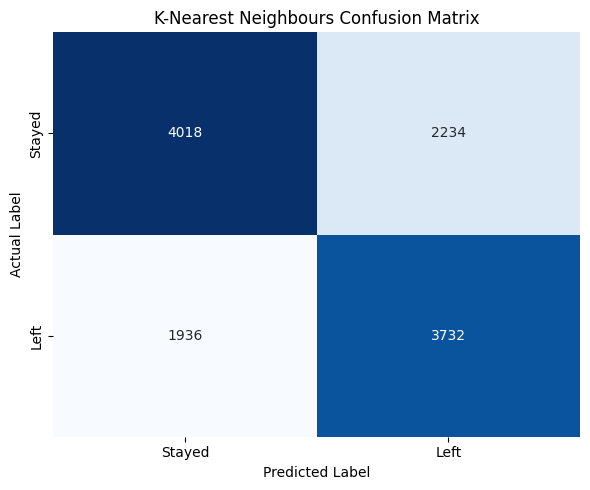


Stored K-Nearest Neighbours Results
Model: K-Nearest Neighbours
Accuracy: 0.6501677852348994
Precision: 0.6255447536037546
Recall: 0.6584333098094566
F1-Score: 0.6415678184631253
Training Time (s): 0.00482976300008886
Testing Time (s): 2.9728504529998645
Training Complexity: O(1)
Prediction Complexity: O(n × d)
Classification Report:               precision    recall  f1-score   support

           0       0.67      0.64      0.66      6252
           1       0.63      0.66      0.64      5668

    accuracy                           0.65     11920
   macro avg       0.65      0.65      0.65     11920
weighted avg       0.65      0.65      0.65     11920

Confusion Matrix: [[4018 2234]
 [1936 3732]]


In [9]:
# I imported the required libraries.
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import matplotlib.pyplot as plt
import seaborn as sns
import time

# I recorded the model training start time.
knn_train_start_time = time.perf_counter()

# I created the K-Nearest Neighbours model.
knn_model = KNeighborsClassifier(
    n_neighbors=5,
    weights="uniform",
    metric="minkowski"
)

# I trained the K-Nearest Neighbours model.
knn_model.fit(
    X_train_smote_scaled,
    y_train_smote
)

# I calculated the model training time.
knn_training_time = time.perf_counter() - knn_train_start_time

# I recorded the prediction start time.
knn_test_start_time = time.perf_counter()

# I predicted the employee attrition for the validation dataset.
knn_predictions = knn_model.predict(
    X_valid_scaled
)

# I calculated the model prediction time.
knn_testing_time = time.perf_counter() - knn_test_start_time

# I calculated the evaluation metrics.
knn_accuracy = accuracy_score(
    y_valid,
    knn_predictions
)

knn_precision = precision_score(
    y_valid,
    knn_predictions
)

knn_recall = recall_score(
    y_valid,
    knn_predictions
)

knn_f1_score = f1_score(
    y_valid,
    knn_predictions
)

# I generated the classification report.
knn_classification_report = classification_report(
    y_valid,
    knn_predictions
)

# I generated the confusion matrix.
knn_confusion_matrix = confusion_matrix(
    y_valid,
    knn_predictions
)

# I stored the algorithm complexity.
knn_training_complexity = "O(1)"
knn_prediction_complexity = "O(n × d)"

# I displayed the evaluation metrics.
print("K-Nearest Neighbours Performance")

print(f"\nAccuracy: {knn_accuracy:.4f}")
print(f"Precision: {knn_precision:.4f}")
print(f"Recall: {knn_recall:.4f}")
print(f"F1-Score: {knn_f1_score:.4f}")

print("\nEfficiency Metrics")
print(f"Training Time (seconds): {knn_training_time:.6f}")
print(f"Testing Time (seconds): {knn_testing_time:.6f}")
print(f"Training Complexity: {knn_training_complexity}")
print(f"Prediction Complexity: {knn_prediction_complexity}")

print("\nClassification Report")
print(knn_classification_report)

print("Confusion Matrix")
print(knn_confusion_matrix)

# I visualised the confusion matrix.
plt.figure(figsize=(6,5))

sns.heatmap(
    knn_confusion_matrix,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    xticklabels=["Stayed", "Left"],
    yticklabels=["Stayed", "Left"]
)

plt.title("K-Nearest Neighbours Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.tight_layout()

plt.show()

# I stored the evaluation results for future comparison.
knn_results = {
    "Model": "K-Nearest Neighbours",
    "Accuracy": knn_accuracy,
    "Precision": knn_precision,
    "Recall": knn_recall,
    "F1-Score": knn_f1_score,
    "Training Time (s)": knn_training_time,
    "Testing Time (s)": knn_testing_time,
    "Training Complexity": knn_training_complexity,
    "Prediction Complexity": knn_prediction_complexity,
    "Classification Report": knn_classification_report,
    "Confusion Matrix": knn_confusion_matrix
}

# I displayed the stored evaluation results.
print("\nStored K-Nearest Neighbours Results")

for key, value in knn_results.items():
    print(f"{key}: {value}")

# Model 3 : LightGBM

In [10]:
!pip install lightgbm

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 25008, number of negative: 25008
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006181 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 643
[LightGBM] [Info] Number of data points in the train set: 50016, number of used features: 23
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
LightGBM Performance

Accuracy: 0.7220
Precision: 0.7013
Recall: 0.7234
F1-Score: 0.7122

Efficiency Metrics
Training Time (seconds): 0.888682
Testing Time (seconds): 0.076638
Training Complexity: O(t × n × log n)
Prediction Complexity: O(t × depth)

Classification Report
              precision    recall  f1-score   support

           0       0.74      0.72      0.73      6252
           1       0.70      0.72   

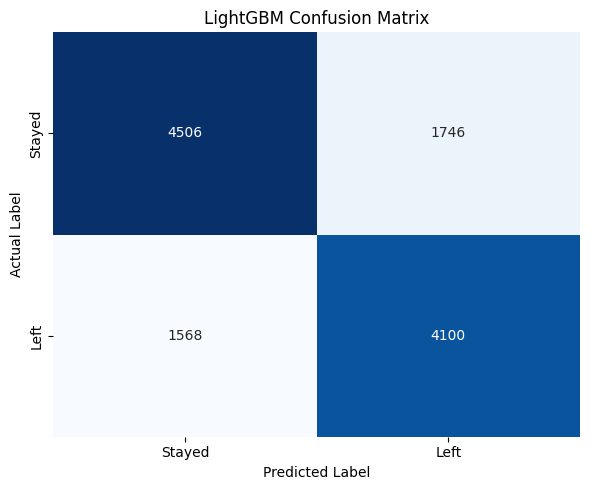


Stored LightGBM Results
Model: LightGBM
Accuracy: 0.7219798657718121
Precision: 0.7013342456380431
Recall: 0.7233592095977417
F1-Score: 0.7121764808059753
Training Time (s): 0.8886822610002127
Testing Time (s): 0.07663787100000263
Training Complexity: O(t × n × log n)
Prediction Complexity: O(t × depth)
Classification Report:               precision    recall  f1-score   support

           0       0.74      0.72      0.73      6252
           1       0.70      0.72      0.71      5668

    accuracy                           0.72     11920
   macro avg       0.72      0.72      0.72     11920
weighted avg       0.72      0.72      0.72     11920

Confusion Matrix: [[4506 1746]
 [1568 4100]]


In [11]:
# I imported the required libraries.
from lightgbm import LGBMClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import matplotlib.pyplot as plt
import seaborn as sns
import time

# I recorded the model training start time.
lgbm_train_start_time = time.perf_counter()

# I created the LightGBM model.
lightgbm_model = LGBMClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=-1,
    random_state=42
)

# I trained the LightGBM model.
lightgbm_model.fit(
    X_train_smote,
    y_train_smote
)

# I calculated the model training time.
lgbm_training_time = time.perf_counter() - lgbm_train_start_time

# I recorded the prediction start time.
lgbm_test_start_time = time.perf_counter()

# I predicted the employee attrition for the validation dataset.
lgbm_predictions = lightgbm_model.predict(
    X_valid
)

# I calculated the model prediction time.
lgbm_testing_time = time.perf_counter() - lgbm_test_start_time

# I calculated the evaluation metrics.
lgbm_accuracy = accuracy_score(y_valid, lgbm_predictions)
lgbm_precision = precision_score(y_valid, lgbm_predictions)
lgbm_recall = recall_score(y_valid, lgbm_predictions)
lgbm_f1_score = f1_score(y_valid, lgbm_predictions)

# I generated the classification report.
lgbm_classification_report = classification_report(
    y_valid,
    lgbm_predictions
)

# I generated the confusion matrix.
lgbm_confusion_matrix = confusion_matrix(
    y_valid,
    lgbm_predictions
)

# I stored the algorithm complexity.
lgbm_training_complexity = "O(t × n × log n)"
lgbm_prediction_complexity = "O(t × depth)"

# I displayed the evaluation metrics.
print("LightGBM Performance")

print(f"\nAccuracy: {lgbm_accuracy:.4f}")
print(f"Precision: {lgbm_precision:.4f}")
print(f"Recall: {lgbm_recall:.4f}")
print(f"F1-Score: {lgbm_f1_score:.4f}")

print("\nEfficiency Metrics")
print(f"Training Time (seconds): {lgbm_training_time:.6f}")
print(f"Testing Time (seconds): {lgbm_testing_time:.6f}")
print(f"Training Complexity: {lgbm_training_complexity}")
print(f"Prediction Complexity: {lgbm_prediction_complexity}")

print("\nClassification Report")
print(lgbm_classification_report)

print("Confusion Matrix")
print(lgbm_confusion_matrix)

# I visualised the confusion matrix.
plt.figure(figsize=(6,5))

sns.heatmap(
    lgbm_confusion_matrix,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    xticklabels=["Stayed", "Left"],
    yticklabels=["Stayed", "Left"]
)

plt.title("LightGBM Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.tight_layout()
plt.show()

# I stored the evaluation results for future comparison.
lgbm_results = {
    "Model": "LightGBM",
    "Accuracy": lgbm_accuracy,
    "Precision": lgbm_precision,
    "Recall": lgbm_recall,
    "F1-Score": lgbm_f1_score,
    "Training Time (s)": lgbm_training_time,
    "Testing Time (s)": lgbm_testing_time,
    "Training Complexity": lgbm_training_complexity,
    "Prediction Complexity": lgbm_prediction_complexity,
    "Classification Report": lgbm_classification_report,
    "Confusion Matrix": lgbm_confusion_matrix
}

# I displayed the stored evaluation results.
print("\nStored LightGBM Results")

for key, value in lgbm_results.items():
    print(f"{key}: {value}")

# Model 4 : Artificial Neural Network (ANN)

Epoch 1/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 23s 11ms/step - accuracy: 0.6892 - loss: 0.5864 - val_accuracy: 0.7046 - val_loss: 0.5635
Epoch 2/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7099 - loss: 0.5582 - val_accuracy: 0.7084 - val_loss: 0.5617
Epoch 3/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7166 - loss: 0.5522 - val_accuracy: 0.7110 - val_loss: 0.5552
Epoch 4/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7192 - loss: 0.5477 - val_accuracy: 0.7107 - val_loss: 0.5571
Epoch 5/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7211 - loss: 0.5460 - val_accuracy: 0.7138 - val_loss: 0.5521
Epoch 6/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7221 - loss: 0.5426 - val_accuracy: 0.7135 - val_loss: 0.5525
Epoch 7/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7238 - loss: 0.5405 - val_accuracy: 0.7122 - val_loss: 0.5530
Epoch 8/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7243 - loss: 0.5398 - val_accuracy: 

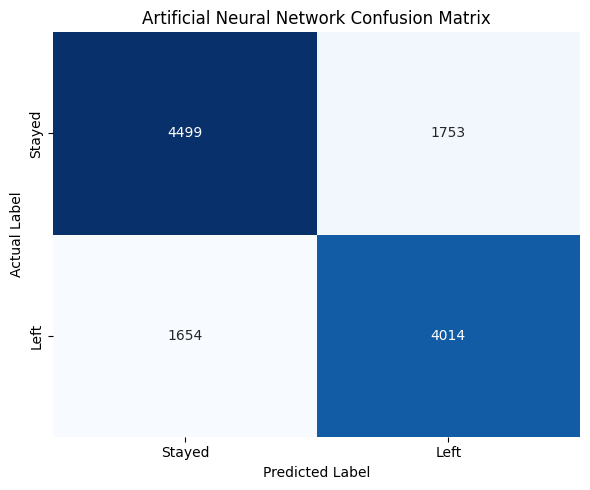

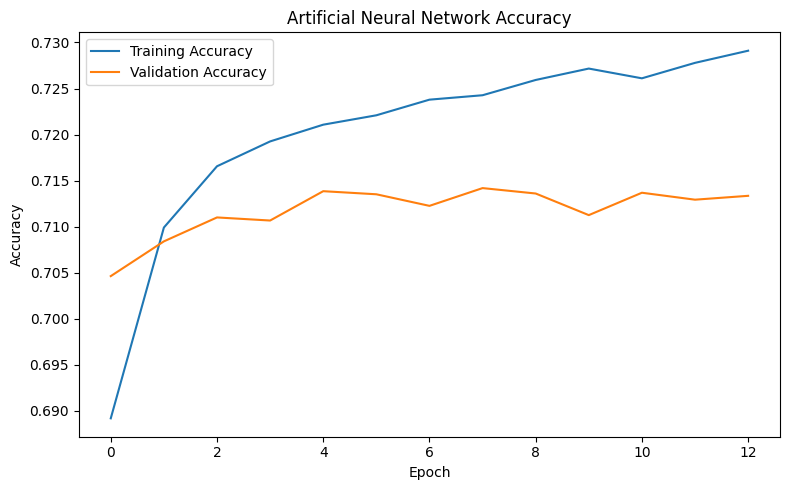

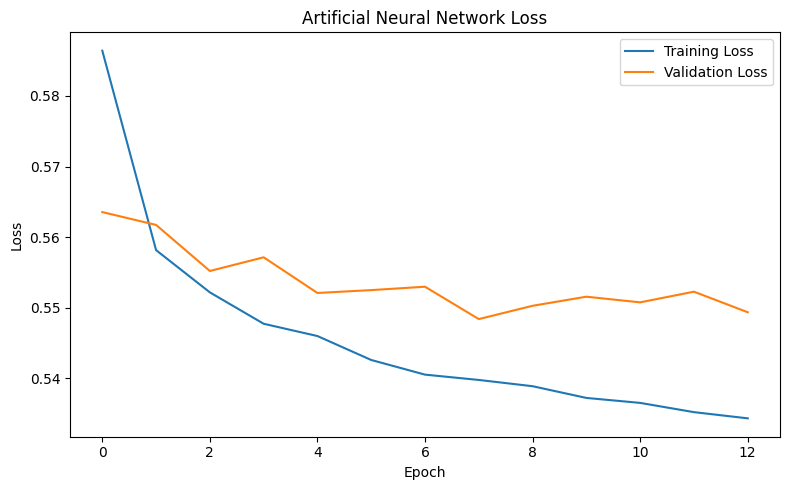


Stored Artificial Neural Network Results
Model: Artificial Neural Network
Accuracy: 0.7141778523489933
Precision: 0.6960291312640888
Recall: 0.7081863091037403
F1-Score: 0.7020550940096196
Training Time (s): 62.75579808099974
Testing Time (s): 1.6472871570003917
Training Complexity: O(E × n × w)
Prediction Complexity: O(w)
Classification Report:               precision    recall  f1-score   support

           0       0.73      0.72      0.73      6252
           1       0.70      0.71      0.70      5668

    accuracy                           0.71     11920
   macro avg       0.71      0.71      0.71     11920
weighted avg       0.71      0.71      0.71     11920

Confusion Matrix: [[4499 1753]
 [1654 4014]]


In [12]:
# I imported the required libraries.
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import time

# I recorded the model training start time.
ann_train_start_time = time.perf_counter()

# I created the Artificial Neural Network model.
ann_model = Sequential()

ann_model.add(Input(shape=(X_train_smote_scaled.shape[1],)))

ann_model.add(Dense(256, activation="relu"))
ann_model.add(BatchNormalization())
ann_model.add(Dropout(0.30))

ann_model.add(Dense(128, activation="relu"))
ann_model.add(BatchNormalization())
ann_model.add(Dropout(0.30))

ann_model.add(Dense(64, activation="relu"))
ann_model.add(BatchNormalization())
ann_model.add(Dropout(0.20))

ann_model.add(Dense(32, activation="relu"))

ann_model.add(Dense(1, activation="sigmoid"))

# I compiled the Artificial Neural Network model.
ann_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# I created the early stopping callback.
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

# I trained the Artificial Neural Network model.
ann_history = ann_model.fit(
    X_train_smote_scaled,
    y_train_smote,
    validation_data=(X_valid_scaled, y_valid),
    epochs=20,
    batch_size=64,
    callbacks=[early_stopping],
    verbose=1
)

# I calculated the model training time.
ann_training_time = time.perf_counter() - ann_train_start_time

# I recorded the prediction start time.
ann_test_start_time = time.perf_counter()

# I predicted the employee attrition probabilities.
ann_probabilities = ann_model.predict(X_valid_scaled)

# I converted probabilities into class labels.
ann_predictions = (ann_probabilities >= 0.5).astype(int).flatten()

# I calculated the model prediction time.
ann_testing_time = time.perf_counter() - ann_test_start_time

# I calculated the evaluation metrics.
ann_accuracy = accuracy_score(y_valid, ann_predictions)

ann_precision = precision_score(
    y_valid,
    ann_predictions
)

ann_recall = recall_score(
    y_valid,
    ann_predictions
)

ann_f1_score = f1_score(
    y_valid,
    ann_predictions
)

# I generated the classification report.
ann_classification_report = classification_report(
    y_valid,
    ann_predictions
)

# I generated the confusion matrix.
ann_confusion_matrix = confusion_matrix(
    y_valid,
    ann_predictions
)

# I stored the algorithm complexity.
ann_training_complexity = "O(E × n × w)"
ann_prediction_complexity = "O(w)"

# I displayed the evaluation metrics.
print("Artificial Neural Network Performance")

print(f"\nAccuracy: {ann_accuracy:.4f}")
print(f"Precision: {ann_precision:.4f}")
print(f"Recall: {ann_recall:.4f}")
print(f"F1-Score: {ann_f1_score:.4f}")

print("\nEfficiency Metrics")

print(f"Training Time (seconds): {ann_training_time:.6f}")
print(f"Testing Time (seconds): {ann_testing_time:.6f}")
print(f"Training Complexity: {ann_training_complexity}")
print(f"Prediction Complexity: {ann_prediction_complexity}")

print("\nClassification Report")
print(ann_classification_report)

print("Confusion Matrix")
print(ann_confusion_matrix)

# I visualised the confusion matrix.
plt.figure(figsize=(6,5))

sns.heatmap(
    ann_confusion_matrix,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    xticklabels=["Stayed", "Left"],
    yticklabels=["Stayed", "Left"]
)

plt.title("Artificial Neural Network Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.tight_layout()
plt.show()

# I visualised the training accuracy.
plt.figure(figsize=(8,5))

plt.plot(ann_history.history["accuracy"], label="Training Accuracy")
plt.plot(ann_history.history["val_accuracy"], label="Validation Accuracy")

plt.title("Artificial Neural Network Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

# I visualised the training loss.
plt.figure(figsize=(8,5))

plt.plot(ann_history.history["loss"], label="Training Loss")
plt.plot(ann_history.history["val_loss"], label="Validation Loss")

plt.title("Artificial Neural Network Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

# I stored the evaluation results for future comparison.
ann_results = {
    "Model": "Artificial Neural Network",
    "Accuracy": ann_accuracy,
    "Precision": ann_precision,
    "Recall": ann_recall,
    "F1-Score": ann_f1_score,
    "Training Time (s)": ann_training_time,
    "Testing Time (s)": ann_testing_time,
    "Training Complexity": ann_training_complexity,
    "Prediction Complexity": ann_prediction_complexity,
    "Classification Report": ann_classification_report,
    "Confusion Matrix": ann_confusion_matrix
}

# I displayed the stored evaluation results.
print("\nStored Artificial Neural Network Results")

for key, value in ann_results.items():
    print(f"{key}: {value}")

# Comparative Table for all Models

In [13]:
# I imported the pandas library.
import pandas as pd

# I created a comparative results table.
comparison_table = pd.DataFrame([

    {
        "Model": lr_results["Model"],
        "Accuracy": lr_results["Accuracy"],
        "Precision": lr_results["Precision"],
        "Recall": lr_results["Recall"],
        "F1-Score": lr_results["F1-Score"],
        "Training Time (s)": lr_results["Training Time (s)"],
        "Testing Time (s)": lr_results["Testing Time (s)"],
        "Training Complexity": lr_results["Training Complexity"],
        "Prediction Complexity": lr_results["Prediction Complexity"]
    },

    {
        "Model": knn_results["Model"],
        "Accuracy": knn_results["Accuracy"],
        "Precision": knn_results["Precision"],
        "Recall": knn_results["Recall"],
        "F1-Score": knn_results["F1-Score"],
        "Training Time (s)": knn_results["Training Time (s)"],
        "Testing Time (s)": knn_results["Testing Time (s)"],
        "Training Complexity": knn_results["Training Complexity"],
        "Prediction Complexity": knn_results["Prediction Complexity"]
    },

    {
        "Model": lgbm_results["Model"],
        "Accuracy": lgbm_results["Accuracy"],
        "Precision": lgbm_results["Precision"],
        "Recall": lgbm_results["Recall"],
        "F1-Score": lgbm_results["F1-Score"],
        "Training Time (s)": lgbm_results["Training Time (s)"],
        "Testing Time (s)": lgbm_results["Testing Time (s)"],
        "Training Complexity": lgbm_results["Training Complexity"],
        "Prediction Complexity": lgbm_results["Prediction Complexity"]
    },

    {
        "Model": ann_results["Model"],
        "Accuracy": ann_results["Accuracy"],
        "Precision": ann_results["Precision"],
        "Recall": ann_results["Recall"],
        "F1-Score": ann_results["F1-Score"],
        "Training Time (s)": ann_results["Training Time (s)"],
        "Testing Time (s)": ann_results["Testing Time (s)"],
        "Training Complexity": ann_results["Training Complexity"],
        "Prediction Complexity": ann_results["Prediction Complexity"]
    }

])

# I rounded the numerical values.
comparison_table[[
    "Accuracy",
    "Precision",
    "Recall",
    "F1-Score",
    "Training Time (s)",
    "Testing Time (s)"
]] = comparison_table[[
    "Accuracy",
    "Precision",
    "Recall",
    "F1-Score",
    "Training Time (s)",
    "Testing Time (s)"
]].round(4)

# I displayed the comparative table.
print("Comparative Performance of Machine Learning and Deep Learning Models")

display(comparison_table)

Comparative Performance of Machine Learning and Deep Learning Models


,Model,Accuracy,Precision,Recall,F1-Score,Training Time (s),Testing Time (s),Training Complexity,Prediction Complexity
0,Logistic Regression,0.7049,0.6838,0.7057,0.6946,0.0738,0.0009,O(n × d),O(d)
1,K-Nearest Neighbours,0.6502,0.6255,0.6584,0.6416,0.0048,2.9729,O(1),O(n × d)
2,LightGBM,0.7220,0.7013,0.7234,0.7122,0.8887,0.0766,O(t × n × log n),O(t × depth)
3,Artificial Neural Network,0.7142,0.6960,0.7082,0.7021,62.7558,1.6473,O(E × n × w),O(w)


# Combined Bar Graphs for all Models

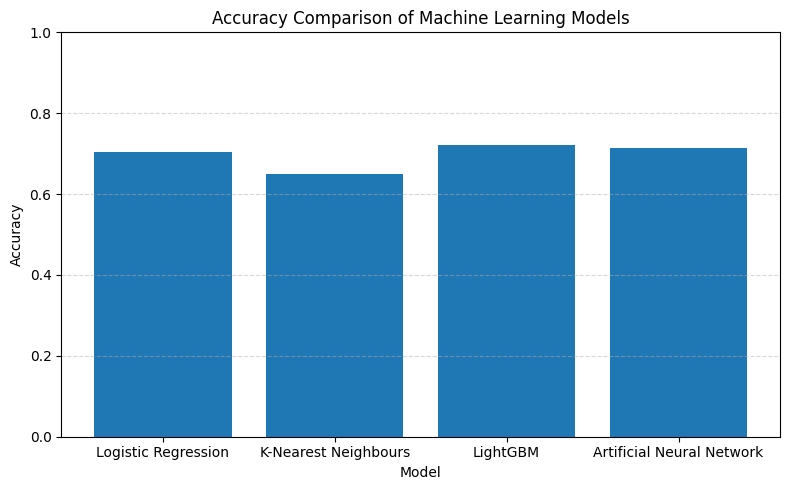

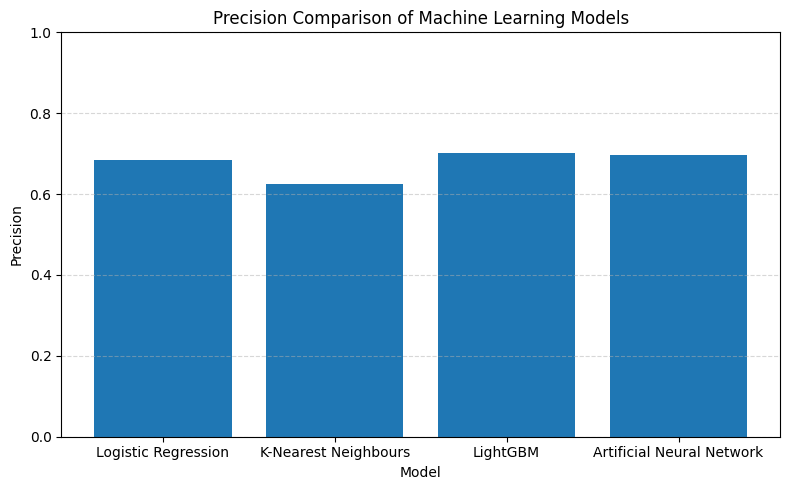

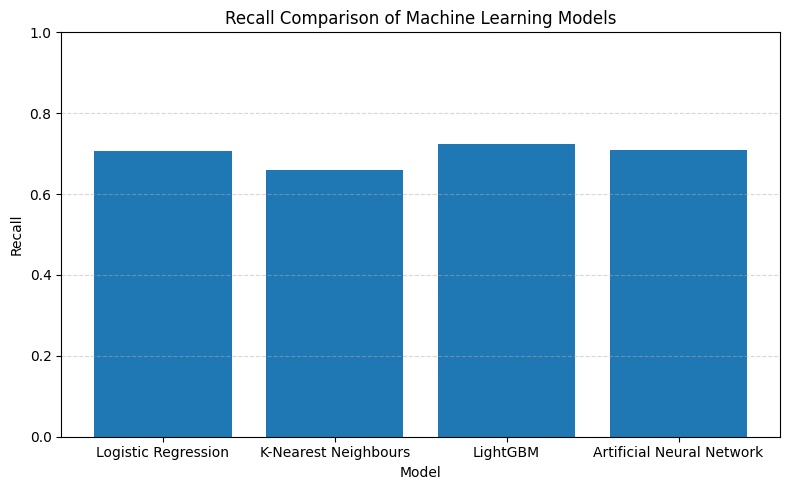

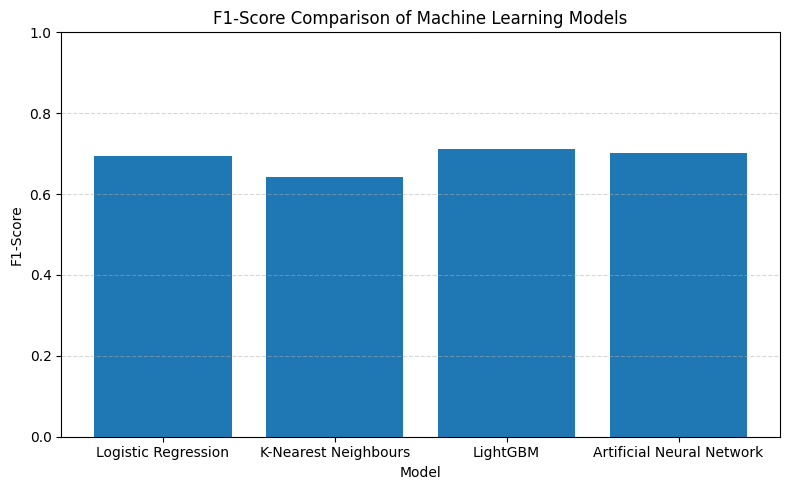

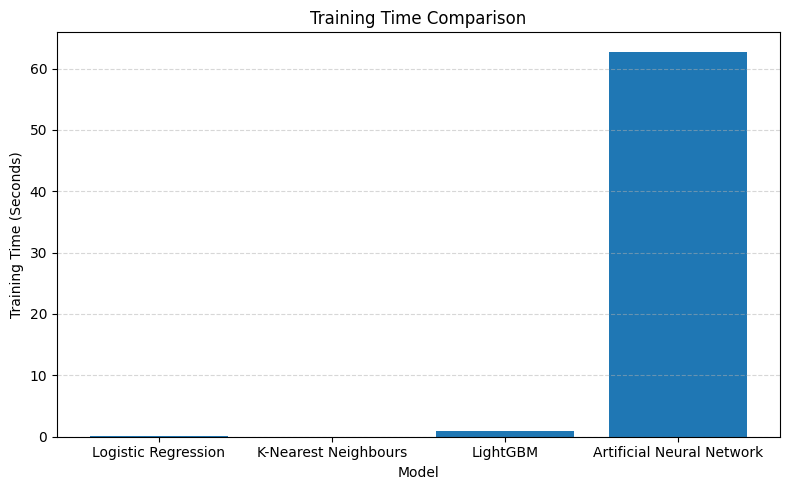

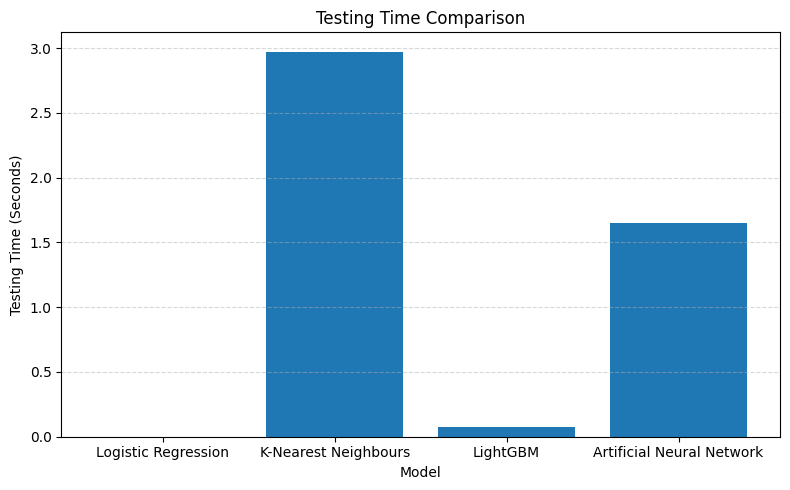

In [14]:
# I imported the required libraries.
import matplotlib.pyplot as plt

# I created a comparison of model accuracy.
plt.figure(figsize=(8,5))

plt.bar(
    comparison_table["Model"],
    comparison_table["Accuracy"]
)

plt.title("Accuracy Comparison of Machine Learning Models")
plt.xlabel("Model")
plt.ylabel("Accuracy")

plt.ylim(0,1)

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()

plt.show()

# I created a comparison of precision.
plt.figure(figsize=(8,5))

plt.bar(
    comparison_table["Model"],
    comparison_table["Precision"]
)

plt.title("Precision Comparison of Machine Learning Models")
plt.xlabel("Model")
plt.ylabel("Precision")

plt.ylim(0,1)

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()

plt.show()

# I created a comparison of recall.
plt.figure(figsize=(8,5))

plt.bar(
    comparison_table["Model"],
    comparison_table["Recall"]
)

plt.title("Recall Comparison of Machine Learning Models")
plt.xlabel("Model")
plt.ylabel("Recall")

plt.ylim(0,1)

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()

plt.show()

# I created a comparison of F1-score.
plt.figure(figsize=(8,5))

plt.bar(
    comparison_table["Model"],
    comparison_table["F1-Score"]
)

plt.title("F1-Score Comparison of Machine Learning Models")
plt.xlabel("Model")
plt.ylabel("F1-Score")

plt.ylim(0,1)

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()

plt.show()

# I created a comparison of training time.
plt.figure(figsize=(8,5))

plt.bar(
    comparison_table["Model"],
    comparison_table["Training Time (s)"]
)

plt.title("Training Time Comparison")
plt.xlabel("Model")
plt.ylabel("Training Time (Seconds)")

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()

plt.show()

# I created a comparison of testing time.
plt.figure(figsize=(8,5))

plt.bar(
    comparison_table["Model"],
    comparison_table["Testing Time (s)"]
)

plt.title("Testing Time Comparison")
plt.xlabel("Model")
plt.ylabel("Testing Time (Seconds)")

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()

plt.show()

# Combined Bar Graph

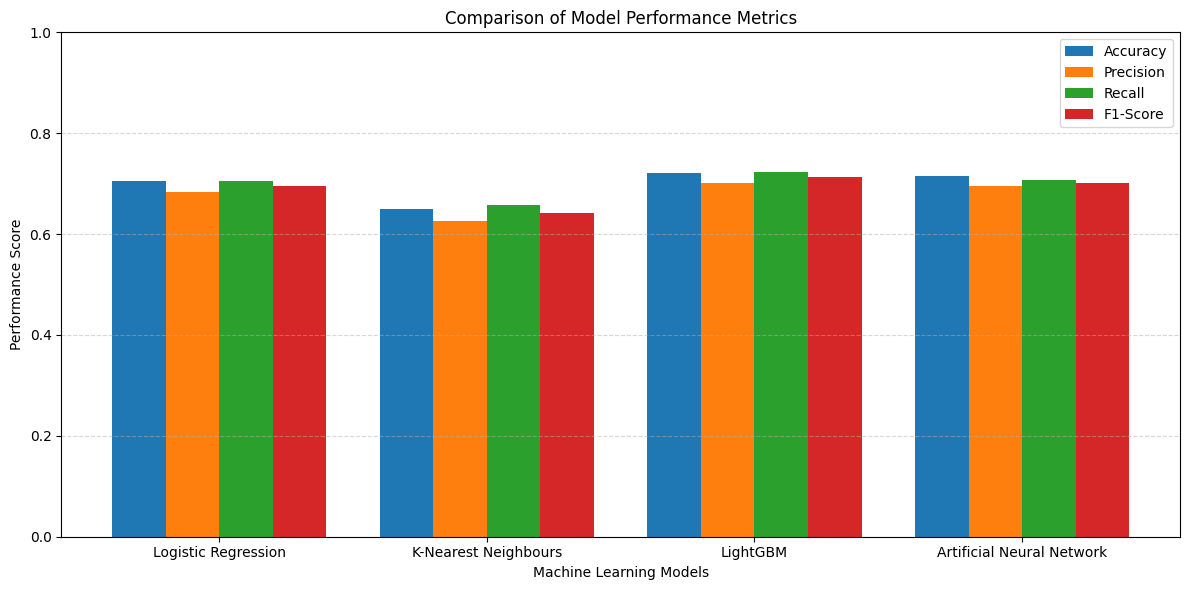

In [15]:
# I imported NumPy.
import numpy as np

x = np.arange(len(comparison_table))

width = 0.20

plt.figure(figsize=(12,6))

plt.bar(
    x - 1.5*width,
    comparison_table["Accuracy"],
    width,
    label="Accuracy"
)

plt.bar(
    x - 0.5*width,
    comparison_table["Precision"],
    width,
    label="Precision"
)

plt.bar(
    x + 0.5*width,
    comparison_table["Recall"],
    width,
    label="Recall"
)

plt.bar(
    x + 1.5*width,
    comparison_table["F1-Score"],
    width,
    label="F1-Score"
)

plt.xticks(
    x,
    comparison_table["Model"]
)

plt.ylim(0,1)

plt.xlabel("Machine Learning Models")
plt.ylabel("Performance Score")
plt.title("Comparison of Model Performance Metrics")

plt.legend()

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()

plt.show()

# Hyper Parameter Tuning

# Model 1 : Tuned Logistic Regression

Optimised Logistic Regression

Best Parameters
{'C': 1, 'penalty': 'l2', 'solver': 'liblinear'}

Accuracy: 0.7049
Precision: 0.6838
Recall: 0.7059
F1-Score: 0.6947

Optimisation Time: 5.3350 seconds

Classification Report
              precision    recall  f1-score   support

           0       0.73      0.70      0.71      6252
           1       0.68      0.71      0.69      5668

    accuracy                           0.70     11920
   macro avg       0.70      0.70      0.70     11920
weighted avg       0.71      0.70      0.71     11920

Confusion Matrix
[[4402 1850]
 [1667 4001]]


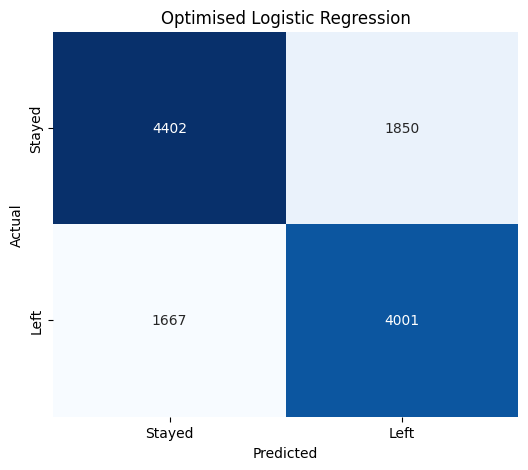

In [16]:
# I imported the required libraries.
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import matplotlib.pyplot as plt
import seaborn as sns
import time

# I defined the hyperparameter grid.
lr_parameter_grid = {
    "C": [0.01, 0.1, 1, 10, 100],
    "solver": ["lbfgs", "liblinear"],
    "penalty": ["l2"]
}

# I created the Logistic Regression model.
lr_base_model = LogisticRegression(
    random_state=42,
    max_iter=5000
)

# I recorded the optimisation start time.
lr_optimisation_start = time.perf_counter()

# I performed Grid Search Cross Validation.
lr_grid_search = GridSearchCV(
    estimator=lr_base_model,
    param_grid=lr_parameter_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

lr_grid_search.fit(
    X_train_smote_scaled,
    y_train_smote
)

# I calculated the optimisation time.
lr_optimisation_time = time.perf_counter() - lr_optimisation_start

# I selected the best model.
best_logistic_model = lr_grid_search.best_estimator_

# I predicted the validation dataset.
lr_best_predictions = best_logistic_model.predict(
    X_valid_scaled
)

# I calculated the evaluation metrics.
lr_best_accuracy = accuracy_score(
    y_valid,
    lr_best_predictions
)

lr_best_precision = precision_score(
    y_valid,
    lr_best_predictions
)

lr_best_recall = recall_score(
    y_valid,
    lr_best_predictions
)

lr_best_f1 = f1_score(
    y_valid,
    lr_best_predictions
)

lr_best_report = classification_report(
    y_valid,
    lr_best_predictions
)

lr_best_confusion_matrix = confusion_matrix(
    y_valid,
    lr_best_predictions
)

print("Optimised Logistic Regression")

print("\nBest Parameters")
print(lr_grid_search.best_params_)

print(f"\nAccuracy: {lr_best_accuracy:.4f}")
print(f"Precision: {lr_best_precision:.4f}")
print(f"Recall: {lr_best_recall:.4f}")
print(f"F1-Score: {lr_best_f1:.4f}")

print(f"\nOptimisation Time: {lr_optimisation_time:.4f} seconds")

print("\nClassification Report")
print(lr_best_report)

print("Confusion Matrix")
print(lr_best_confusion_matrix)

plt.figure(figsize=(6,5))

sns.heatmap(
    lr_best_confusion_matrix,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    xticklabels=["Stayed","Left"],
    yticklabels=["Stayed","Left"]
)

plt.title("Optimised Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# I stored the optimisation results.
optimised_lr_results = {
    "Model":"Optimised Logistic Regression",
    "Accuracy":lr_best_accuracy,
    "Precision":lr_best_precision,
    "Recall":lr_best_recall,
    "F1-Score":lr_best_f1,
    "Best Parameters":lr_grid_search.best_params_,
    "Optimisation Time":lr_optimisation_time
}

# Model 2 : Tuned KNN

/usr/local/lib/python3.12/dist-packages/numpy/ma/core.py:2846: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


Optimised K-Nearest Neighbours Performance

Best Hyperparameters
{'metric': 'manhattan', 'n_neighbors': 7, 'weights': 'distance'}

Accuracy: 0.6611
Precision: 0.6322
Recall: 0.6867
F1-Score: 0.6583

Efficiency Metrics
Optimisation Time (seconds): 362.0737
Prediction Time (seconds): 15.147811
Training Complexity: O(1)
Prediction Complexity: O(n × d)

Classification Report
              precision    recall  f1-score   support

           0       0.69      0.64      0.66      6252
           1       0.63      0.69      0.66      5668

    accuracy                           0.66     11920
   macro avg       0.66      0.66      0.66     11920
weighted avg       0.66      0.66      0.66     11920

Confusion Matrix
[[3988 2264]
 [1776 3892]]


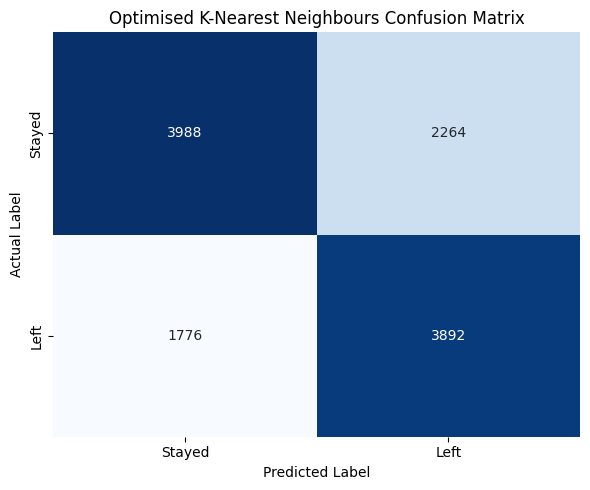


Stored Optimised K-Nearest Neighbours Results
Model: Optimised K-Nearest Neighbours
Accuracy: 0.6610738255033557
Precision: 0.6322287199480182
Recall: 0.6866619618913197
F1-Score: 0.6583220568335588
Optimisation Time (s): 362.07369865300006
Prediction Time (s): 15.147810897999989
Training Complexity: O(1)
Prediction Complexity: O(n × d)
Best Hyperparameters: {'metric': 'manhattan', 'n_neighbors': 7, 'weights': 'distance'}
Classification Report:               precision    recall  f1-score   support

           0       0.69      0.64      0.66      6252
           1       0.63      0.69      0.66      5668

    accuracy                           0.66     11920
   macro avg       0.66      0.66      0.66     11920
weighted avg       0.66      0.66      0.66     11920

Confusion Matrix: [[3988 2264]
 [1776 3892]]


In [17]:
# I imported the required libraries.
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import matplotlib.pyplot as plt
import seaborn as sns
import time

# I defined the hyperparameter search space.
knn_parameter_grid = {
    "n_neighbors": [3, 5, 7],
    "weights": ["uniform", "distance"],
    "metric": ["euclidean", "manhattan"]
}

# I created the KNN model.
knn_base_model = KNeighborsClassifier()

# I recorded the optimisation start time.
knn_optimisation_start = time.perf_counter()

# I performed Grid Search Cross Validation.
knn_grid_search = GridSearchCV(
    estimator=knn_base_model,
    param_grid=knn_parameter_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

# I trained the Grid Search model.
knn_grid_search.fit(
    X_train_smote_scaled,
    y_train_smote
)

# I calculated the optimisation time.
knn_optimisation_time = (
    time.perf_counter() -
    knn_optimisation_start
)

# I obtained the best KNN model.
best_knn_model = knn_grid_search.best_estimator_

# I recorded the prediction start time.
knn_prediction_start = time.perf_counter()

# I predicted the validation dataset.
knn_best_predictions = best_knn_model.predict(
    X_valid_scaled
)

# I calculated the prediction time.
knn_prediction_time = (
    time.perf_counter() -
    knn_prediction_start
)

# I calculated the evaluation metrics.
knn_best_accuracy = accuracy_score(
    y_valid,
    knn_best_predictions
)

knn_best_precision = precision_score(
    y_valid,
    knn_best_predictions
)

knn_best_recall = recall_score(
    y_valid,
    knn_best_predictions
)

knn_best_f1_score = f1_score(
    y_valid,
    knn_best_predictions
)

# I generated the classification report.
knn_best_classification_report = classification_report(
    y_valid,
    knn_best_predictions
)

# I generated the confusion matrix.
knn_best_confusion_matrix = confusion_matrix(
    y_valid,
    knn_best_predictions
)

# I stored the algorithm complexity.
knn_best_training_complexity = "O(1)"
knn_best_prediction_complexity = "O(n × d)"

# I displayed the optimisation results.
print("Optimised K-Nearest Neighbours Performance")

print("\nBest Hyperparameters")
print(knn_grid_search.best_params_)

print(f"\nAccuracy: {knn_best_accuracy:.4f}")
print(f"Precision: {knn_best_precision:.4f}")
print(f"Recall: {knn_best_recall:.4f}")
print(f"F1-Score: {knn_best_f1_score:.4f}")

print("\nEfficiency Metrics")

print(f"Optimisation Time (seconds): {knn_optimisation_time:.4f}")
print(f"Prediction Time (seconds): {knn_prediction_time:.6f}")
print(f"Training Complexity: {knn_best_training_complexity}")
print(f"Prediction Complexity: {knn_best_prediction_complexity}")

print("\nClassification Report")
print(knn_best_classification_report)

print("Confusion Matrix")
print(knn_best_confusion_matrix)

# I visualised the confusion matrix.
plt.figure(figsize=(6,5))

sns.heatmap(
    knn_best_confusion_matrix,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    xticklabels=["Stayed", "Left"],
    yticklabels=["Stayed", "Left"]
)

plt.title("Optimised K-Nearest Neighbours Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.tight_layout()

plt.show()

# I stored the optimisation results.
optimised_knn_results = {
    "Model": "Optimised K-Nearest Neighbours",
    "Accuracy": knn_best_accuracy,
    "Precision": knn_best_precision,
    "Recall": knn_best_recall,
    "F1-Score": knn_best_f1_score,
    "Optimisation Time (s)": knn_optimisation_time,
    "Prediction Time (s)": knn_prediction_time,
    "Training Complexity": knn_best_training_complexity,
    "Prediction Complexity": knn_best_prediction_complexity,
    "Best Hyperparameters": knn_grid_search.best_params_,
    "Classification Report": knn_best_classification_report,
    "Confusion Matrix": knn_best_confusion_matrix
}

# I displayed the stored optimisation results.
print("\nStored Optimised K-Nearest Neighbours Results")

for key, value in optimised_knn_results.items():
    print(f"{key}: {value}")

# Model 3 : Tuned LightGBM

/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/numpy/ma/core.py:2846: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


Optimised LightGBM Performance

Best Hyperparameters
{'learning_rate': 0.05, 'max_depth': -1, 'n_estimators': 100, 'num_leaves': 31}

Accuracy: 0.7234
Precision: 0.7021
Recall: 0.7265
F1-Score: 0.7141

Efficiency Metrics
Training Time (seconds): 346.5104
Testing Time (seconds): 0.091076
Training Complexity: O(t × n × log n)
Prediction Complexity: O(t × depth)

Classification Report
              precision    recall  f1-score   support

           0       0.74      0.72      0.73      6252
           1       0.70      0.73      0.71      5668

    accuracy                           0.72     11920
   macro avg       0.72      0.72      0.72     11920
weighted avg       0.72      0.72      0.72     11920

Confusion Matrix
[[4505 1747]
 [1550 4118]]


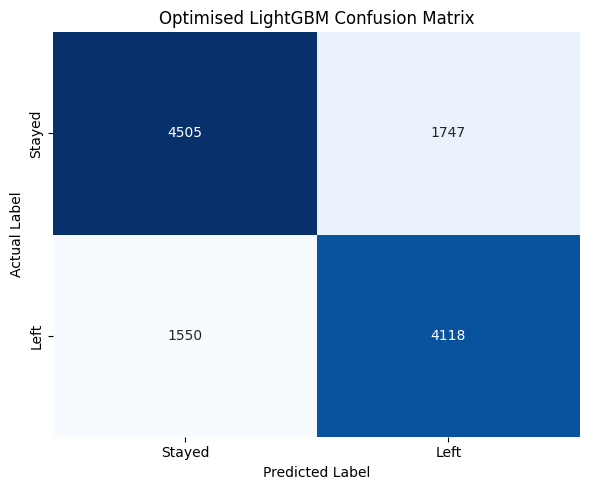


Stored Optimised LightGBM Results
Model: Optimised LightGBM
Accuracy: 0.7234060402684563
Precision: 0.7021312872975277
Recall: 0.7265349329569513
F1-Score: 0.7141246856845573
Training Time (s): 346.51038107999966
Testing Time (s): 0.09107648400004109
Training Complexity: O(t × n × log n)
Prediction Complexity: O(t × depth)
Best Hyperparameters: {'learning_rate': 0.05, 'max_depth': -1, 'n_estimators': 100, 'num_leaves': 31}
Classification Report:               precision    recall  f1-score   support

           0       0.74      0.72      0.73      6252
           1       0.70      0.73      0.71      5668

    accuracy                           0.72     11920
   macro avg       0.72      0.72      0.72     11920
weighted avg       0.72      0.72      0.72     11920

Confusion Matrix: [[4505 1747]
 [1550 4118]]


In [19]:
# I imported the required libraries.
from lightgbm import LGBMClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import matplotlib.pyplot as plt
import seaborn as sns
import time

# I defined the hyperparameter search space.
lgbm_parameter_grid = {
    "n_estimators": [100, 200, 300],
    "learning_rate": [0.01, 0.05, 0.1],
    "num_leaves": [31, 50, 70],
    "max_depth": [-1, 10, 20]
}

# I created the LightGBM model.
lgbm_model = LGBMClassifier(
    random_state=42,
    verbose=-1
)

# I recorded the optimisation start time.
training_start = time.perf_counter()

# I performed Grid Search Cross Validation.
lgbm_grid_search = GridSearchCV(
    estimator=lgbm_model,
    param_grid=lgbm_parameter_grid,
    cv=3,
    scoring="accuracy",
    n_jobs=-1
)

# I trained the model.
lgbm_grid_search.fit(
    X_train_smote,
    y_train_smote
)

# I calculated the optimisation time.
training_time = time.perf_counter() - training_start

# I obtained the best model.
best_lgbm_model = lgbm_grid_search.best_estimator_

# I recorded the prediction start time.
prediction_start = time.perf_counter()

# I predicted the validation dataset.
lgbm_predictions = best_lgbm_model.predict(
    X_valid
)

# I calculated the prediction time.
prediction_time = time.perf_counter() - prediction_start

# I calculated the evaluation metrics.
lgbm_accuracy = accuracy_score(
    y_valid,
    lgbm_predictions
)

lgbm_precision = precision_score(
    y_valid,
    lgbm_predictions
)

lgbm_recall = recall_score(
    y_valid,
    lgbm_predictions
)

lgbm_f1 = f1_score(
    y_valid,
    lgbm_predictions
)

lgbm_report = classification_report(
    y_valid,
    lgbm_predictions
)

lgbm_confusion = confusion_matrix(
    y_valid,
    lgbm_predictions
)

# I stored the algorithm complexity.
lgbm_training_complexity = "O(t × n × log n)"
lgbm_prediction_complexity = "O(t × depth)"

# I displayed the optimisation results.
print("Optimised LightGBM Performance")

print("\nBest Hyperparameters")
print(lgbm_grid_search.best_params_)

print(f"\nAccuracy: {lgbm_accuracy:.4f}")
print(f"Precision: {lgbm_precision:.4f}")
print(f"Recall: {lgbm_recall:.4f}")
print(f"F1-Score: {lgbm_f1:.4f}")

print("\nEfficiency Metrics")

print(f"Training Time (seconds): {training_time:.4f}")
print(f"Testing Time (seconds): {prediction_time:.6f}")

print(f"Training Complexity: {lgbm_training_complexity}")
print(f"Prediction Complexity: {lgbm_prediction_complexity}")

print("\nClassification Report")
print(lgbm_report)

print("Confusion Matrix")
print(lgbm_confusion)

# I visualised the confusion matrix.
plt.figure(figsize=(6,5))

sns.heatmap(
    lgbm_confusion,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    xticklabels=["Stayed", "Left"],
    yticklabels=["Stayed", "Left"]
)

plt.title("Optimised LightGBM Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.tight_layout()

plt.show()

# I stored the optimisation results.
optimised_lgbm_results = {
    "Model": "Optimised LightGBM",
    "Accuracy": lgbm_accuracy,
    "Precision": lgbm_precision,
    "Recall": lgbm_recall,
    "F1-Score": lgbm_f1,
    "Training Time (s)": training_time,
    "Testing Time (s)": prediction_time,
    "Training Complexity": lgbm_training_complexity,
    "Prediction Complexity": lgbm_prediction_complexity,
    "Best Hyperparameters": lgbm_grid_search.best_params_,
    "Classification Report": lgbm_report,
    "Confusion Matrix": lgbm_confusion
}

# I displayed the stored optimisation results.
print("\nStored Optimised LightGBM Results")

for key, value in optimised_lgbm_results.items():
    print(f"{key}: {value}")

In [20]:
!pip install scikeras

# Model 4 : Tuned ANN

Fitting 3 folds for each of 2 candidates, totalling 6 fits
[CV] END epochs=20, model__dropout_rate=0.2, model__learning_rate=0.001, model__neurons=64; total time= 1.1min
[CV] END epochs=20, model__dropout_rate=0.2, model__learning_rate=0.001, model__neurons=64; total time= 1.0min
[CV] END epochs=20, model__dropout_rate=0.2, model__learning_rate=0.001, model__neurons=64; total time= 1.0min
[CV] END epochs=20, model__dropout_rate=0.2, model__learning_rate=0.001, model__neurons=128; total time= 1.1min
[CV] END epochs=20, model__dropout_rate=0.2, model__learning_rate=0.001, model__neurons=128; total time= 1.1min
[CV] END epochs=20, model__dropout_rate=0.2, model__learning_rate=0.001, model__neurons=128; total time= 1.0min
Best Hyperparameters
{'epochs': 20, 'model__dropout_rate': 0.2, 'model__learning_rate': 0.001, 'model__neurons': 64}
Epoch 1/20
1251/1251 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.6737 - loss: 0.5987 - val_accuracy: 0.7691 - val_loss: 0.5030
Epoch 2/20
1251/1251 ━━━

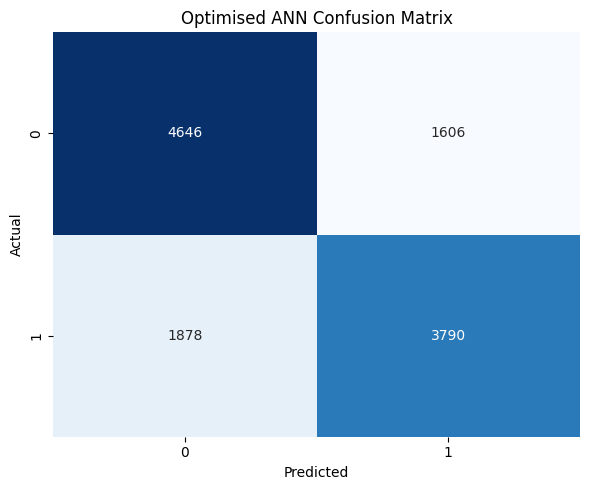

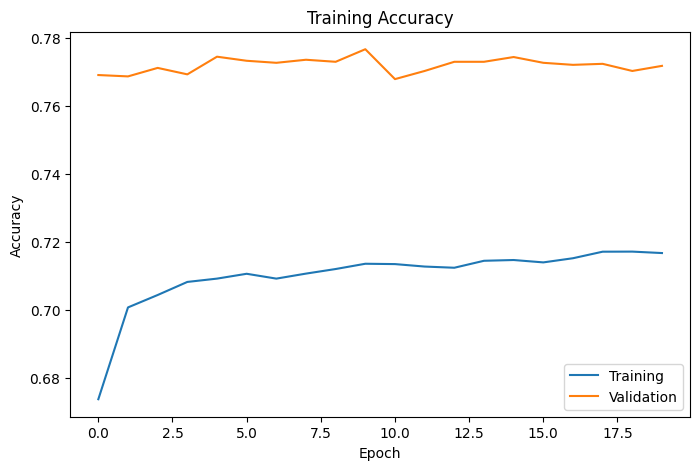

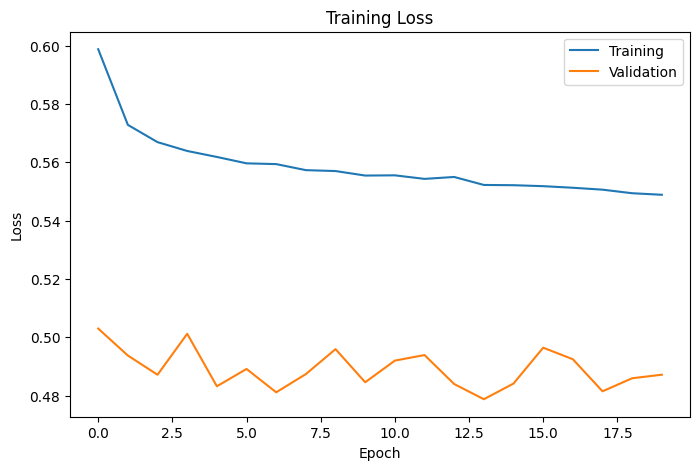

{'Model': 'Optimised ANN', 'Best Hyperparameters': {'epochs': 20, 'model__dropout_rate': 0.2, 'model__learning_rate': 0.001, 'model__neurons': 64}, 'Accuracy': 0.7077181208053691, 'Precision': np.float64(0.7023721275018532), 'Recall': np.float64(0.6686661961891319), 'F1-Score': np.float64(0.6851048445408532), 'ROC-AUC': np.float64(0.7875957745744367), 'Training Time (s)': 464.14867541699914, 'Testing Time (s)': 1.8872992159995192, 'Classification Report': '              precision    recall  f1-score   support\n\n           0       0.71      0.74      0.73      6252\n           1       0.70      0.67      0.69      5668\n\n    accuracy                           0.71     11920\n   macro avg       0.71      0.71      0.71     11920\nweighted avg       0.71      0.71      0.71     11920\n', 'Confusion Matrix': array([[4646, 1606],
       [1878, 3790]])}


In [23]:
import gc
import time
import joblib
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

from scikeras.wrappers import KerasClassifier

from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

# I created the ANN model.
def create_ann(
    neurons=64,
    dropout_rate=0.2,
    learning_rate=0.001
):

    model = Sequential()

    model.add(Input(shape=(X_train_smote_scaled.shape[1],)))
    model.add(Dense(neurons, activation="relu"))
    model.add(Dropout(dropout_rate))

    model.add(Dense(32, activation="relu"))
    model.add(Dropout(dropout_rate))

    model.add(Dense(1, activation="sigmoid"))

    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model


# I created the early stopping callback.
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

# I created the ANN classifier.
ann_classifier = KerasClassifier(
    model=create_ann,
    verbose=0
)

# I defined the reduced hyperparameter grid.
parameter_grid = {

    "model__neurons": [64, 128],

    "model__dropout_rate": [0.2],

    "model__learning_rate": [0.001],

    "epochs": [20]

}

tf.keras.backend.clear_session()
gc.collect()

training_start = time.perf_counter()

grid_search = GridSearchCV(
    estimator=ann_classifier,
    param_grid=parameter_grid,
    scoring="accuracy",
    cv=3,
    n_jobs=1,
    verbose=2
)

grid_search.fit(
    X_train_smote_scaled,
    y_train_smote,
    callbacks=[early_stopping],
    validation_split=0.20
)

training_time = time.perf_counter() - training_start

best_ann_model = grid_search.best_estimator_
best_parameters = grid_search.best_params_

print("Best Hyperparameters")
print(best_parameters)

history = best_ann_model.fit(
    X_train_smote_scaled,
    y_train_smote,
    validation_split=0.20,
    callbacks=[early_stopping],
    verbose=1
)

prediction_start = time.perf_counter()

y_pred = best_ann_model.predict(X_valid_scaled)
y_prob = best_ann_model.predict_proba(X_valid_scaled)[:, 1]

prediction_time = time.perf_counter() - prediction_start

accuracy = accuracy_score(y_valid, y_pred)
precision = precision_score(y_valid, y_pred)
recall = recall_score(y_valid, y_pred)
f1 = f1_score(y_valid, y_pred)
roc_auc = roc_auc_score(y_valid, y_prob)

report = classification_report(y_valid, y_pred)
cm = confusion_matrix(y_valid, y_pred)

print(report)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("Optimised ANN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

try:
    hist = history.history_
except AttributeError:
    hist = history.history

plt.figure(figsize=(8,5))
plt.plot(hist["accuracy"], label="Training")
if "val_accuracy" in hist:
    plt.plot(hist["val_accuracy"], label="Validation")
plt.title("Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

plt.figure(figsize=(8,5))
plt.plot(hist["loss"], label="Training")
if "val_loss" in hist:
    plt.plot(hist["val_loss"], label="Validation")
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

optimised_ann_results = {
    "Model": "Optimised ANN",
    "Best Hyperparameters": best_parameters,
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1-Score": f1,
    "ROC-AUC": roc_auc,
    "Training Time (s)": training_time,
    "Testing Time (s)": prediction_time,
    "Classification Report": report,
    "Confusion Matrix": cm
}


print(optimised_ann_results)


# Comparative Table for all Tuned Models

In [24]:
# I imported the required library.
import pandas as pd

# I created a list of the optimised model results.
optimised_results = [

    optimised_lr_results,

    optimised_lgbm_results,

    optimised_knn_results,

    optimised_ann_results
]

# I created the comparison table.
optimised_models_comparison = pd.DataFrame(optimised_results)

# I rounded the numerical columns.
numerical_columns = [

    "Accuracy",

    "Precision",

    "Recall",

    "F1-Score"

]

optimised_models_comparison[numerical_columns] = (
    optimised_models_comparison[numerical_columns]
    .round(4)
)

# I arranged the columns.
optimised_models_comparison = optimised_models_comparison[

    [

        "Model",

        "Accuracy",

        "Precision",

        "Recall",

        "F1-Score"

    ]

]

# I displayed the comparison table.
print("Comparative Performance of Optimised Models")

display(optimised_models_comparison)

# I identified the best performing model.
best_model = optimised_models_comparison.loc[
    optimised_models_comparison["Accuracy"].idxmax()
]

print("\nBest Performing Optimised Model")

print(best_model)

Comparative Performance of Optimised Models


,Model,Accuracy,Precision,Recall,F1-Score
0,Optimised Logistic Regression,0.7049,0.6838,0.7059,0.6947
1,Optimised LightGBM,0.7234,0.7021,0.7265,0.7141
2,Optimised K-Nearest Neighbours,0.6611,0.6322,0.6867,0.6583
3,Optimised ANN,0.7077,0.7024,0.6687,0.6851



Best Performing Optimised Model
Model        Optimised LightGBM
Accuracy                 0.7234
Precision                0.7021
Recall                   0.7265
F1-Score                 0.7141
Name: 1, dtype: object


# Combined Bar Graphs for Tuned Models

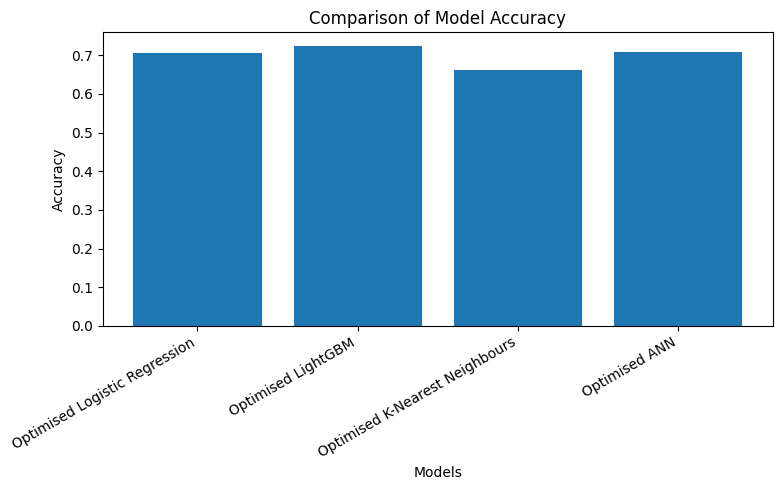

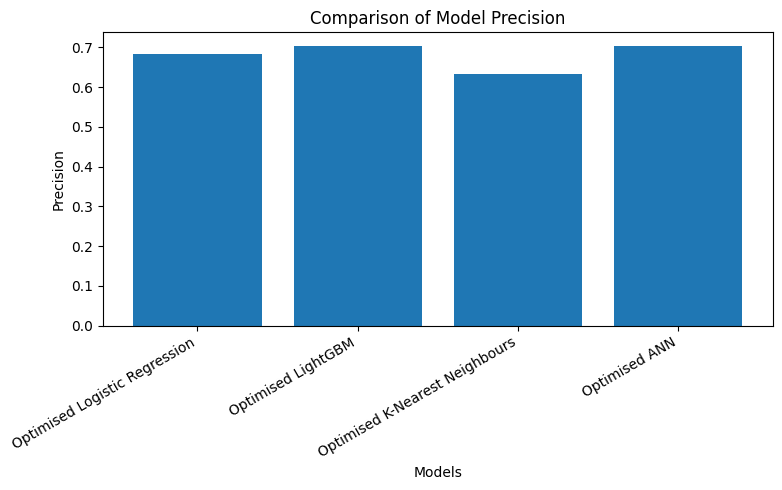

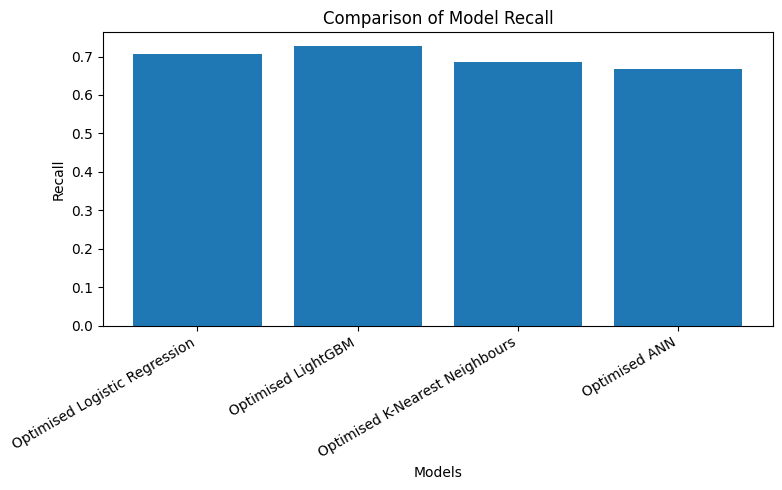

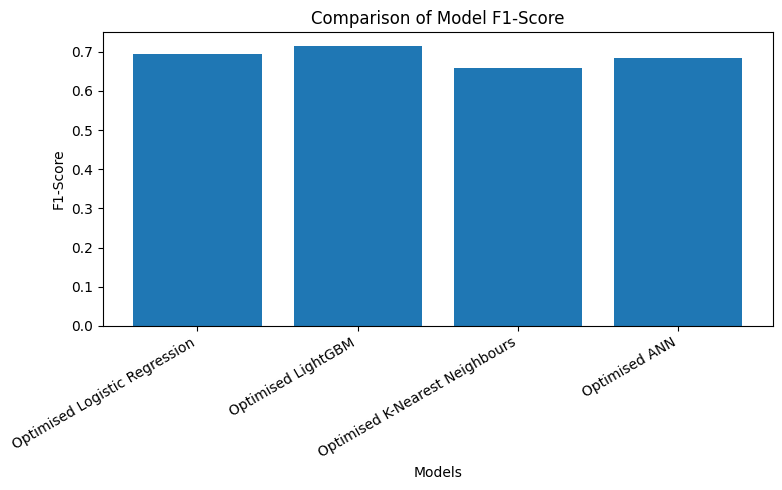

In [25]:
# I imported the required libraries.
import matplotlib.pyplot as plt

# I extracted the model names.
model_names = optimised_models_comparison["Model"]

# I created the Accuracy comparison graph.
plt.figure(figsize=(8,5))

plt.bar(
    model_names,
    optimised_models_comparison["Accuracy"]
)

plt.title("Comparison of Model Accuracy")

plt.xlabel("Models")

plt.ylabel("Accuracy")

plt.xticks(rotation=30, ha="right")

plt.tight_layout()

plt.show()

# I created the Precision comparison graph.
plt.figure(figsize=(8,5))

plt.bar(
    model_names,
    optimised_models_comparison["Precision"]
)

plt.title("Comparison of Model Precision")

plt.xlabel("Models")

plt.ylabel("Precision")

plt.xticks(rotation=30, ha="right")

plt.tight_layout()

plt.show()

# I created the Recall comparison graph.
plt.figure(figsize=(8,5))

plt.bar(
    model_names,
    optimised_models_comparison["Recall"]
)

plt.title("Comparison of Model Recall")

plt.xlabel("Models")

plt.ylabel("Recall")

plt.xticks(rotation=30, ha="right")

plt.tight_layout()

plt.show()

# I created the F1-Score comparison graph.
plt.figure(figsize=(8,5))

plt.bar(
    model_names,
    optimised_models_comparison["F1-Score"]
)

plt.title("Comparison of Model F1-Score")

plt.xlabel("Models")

plt.ylabel("F1-Score")

plt.xticks(rotation=30, ha="right")

plt.tight_layout()

plt.show()

# Visual Analysis

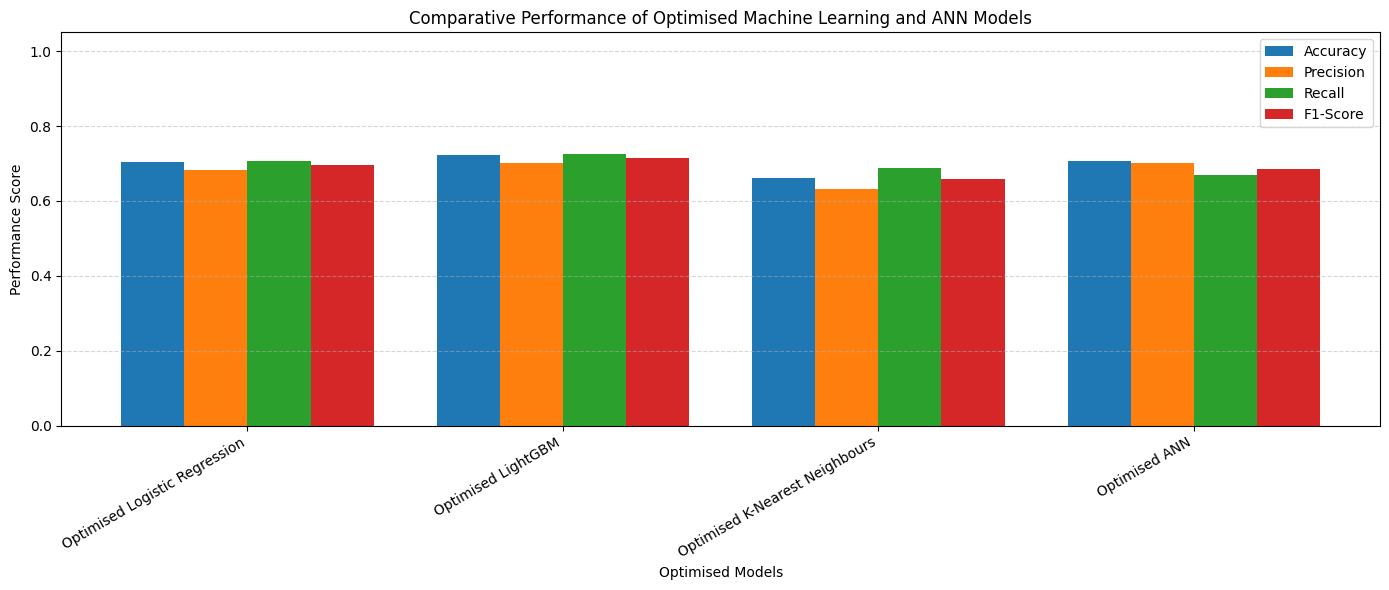

In [26]:
# I imported the required libraries.
import matplotlib.pyplot as plt
import numpy as np

# I extracted the model names.
models = optimised_models_comparison["Model"]

# I extracted the evaluation metrics.
accuracy = optimised_models_comparison["Accuracy"]
precision = optimised_models_comparison["Precision"]
recall = optimised_models_comparison["Recall"]
f1_score = optimised_models_comparison["F1-Score"]

# I defined the bar positions.
x = np.arange(len(models))

bar_width = 0.20

# I created the combined bar chart.
plt.figure(figsize=(14,6))

plt.bar(
    x - 1.5 * bar_width,
    accuracy,
    width=bar_width,
    label="Accuracy"
)

plt.bar(
    x - 0.5 * bar_width,
    precision,
    width=bar_width,
    label="Precision"
)

plt.bar(
    x + 0.5 * bar_width,
    recall,
    width=bar_width,
    label="Recall"
)

plt.bar(
    x + 1.5 * bar_width,
    f1_score,
    width=bar_width,
    label="F1-Score"
)

plt.xticks(
    x,
    models,
    rotation=30,
    ha="right"
)

plt.xlabel("Optimised Models")

plt.ylabel("Performance Score")

plt.title("Comparative Performance of Optimised Machine Learning and ANN Models")

plt.ylim(0, 1.05)

plt.legend()

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()

plt.show()

# Combined Comparative Table for Default and Tuned Models

In [27]:
# I imported the required library.
import pandas as pd

# I created the combined comparison table.
combined_models_comparison = pd.DataFrame([

    {
        "Model": "Logistic Regression (Default)",
        "Accuracy": lr_results["Accuracy"],
        "Precision": lr_results["Precision"],
        "Recall": lr_results["Recall"],
        "F1-Score": lr_results["F1-Score"]
    },

    {
        "Model": "Logistic Regression (Optimised)",
        "Accuracy": optimised_lr_results["Accuracy"],
        "Precision": optimised_lr_results["Precision"],
        "Recall": optimised_lr_results["Recall"],
        "F1-Score": optimised_lr_results["F1-Score"]
    },

    {
        "Model": "KNN (Default)",
        "Accuracy": knn_results["Accuracy"],
        "Precision": knn_results["Precision"],
        "Recall": knn_results["Recall"],
        "F1-Score": knn_results["F1-Score"]
    },

    {
        "Model": "KNN (Optimised)",
        "Accuracy": optimised_knn_results["Accuracy"],
        "Precision": optimised_knn_results["Precision"],
        "Recall": optimised_knn_results["Recall"],
        "F1-Score": optimised_knn_results["F1-Score"]
    },

    {
        "Model": "LightGBM (Default)",
        "Accuracy": lgbm_results["Accuracy"],
        "Precision": lgbm_results["Precision"],
        "Recall": lgbm_results["Recall"],
        "F1-Score": lgbm_results["F1-Score"]
    },

    {
        "Model": "LightGBM (Optimised)",
        "Accuracy": optimised_lgbm_results["Accuracy"],
        "Precision": optimised_lgbm_results["Precision"],
        "Recall": optimised_lgbm_results["Recall"],
        "F1-Score": optimised_lgbm_results["F1-Score"]
    },

    {
        "Model": "ANN (Default)",
        "Accuracy": ann_results["Accuracy"],
        "Precision": ann_results["Precision"],
        "Recall": ann_results["Recall"],
        "F1-Score": ann_results["F1-Score"]
    },

    {
        "Model": "ANN (Optimised)",
        "Accuracy": optimised_ann_results["Accuracy"],
        "Precision": optimised_ann_results["Precision"],
        "Recall": optimised_ann_results["Recall"],
        "F1-Score": optimised_ann_results["F1-Score"]
    }

])

# I rounded the numerical values.
combined_models_comparison[["Accuracy", "Precision", "Recall", "F1-Score"]] = (
    combined_models_comparison[["Accuracy", "Precision", "Recall", "F1-Score"]]
    .round(4)
)

# I displayed the comparison table.
print("Comparison of Default and Optimised Models")

display(combined_models_comparison)

Comparison of Default and Optimised Models


,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression (Default),0.7049,0.6838,0.7057,0.6946
1,Logistic Regression (Optimised),0.7049,0.6838,0.7059,0.6947
2,KNN (Default),0.6502,0.6255,0.6584,0.6416
3,KNN (Optimised),0.6611,0.6322,0.6867,0.6583
4,LightGBM (Default),0.7220,0.7013,0.7234,0.7122
5,LightGBM (Optimised),0.7234,0.7021,0.7265,0.7141
6,ANN (Default),0.7142,0.6960,0.7082,0.7021
7,ANN (Optimised),0.7077,0.7024,0.6687,0.6851


# Visual Analysis

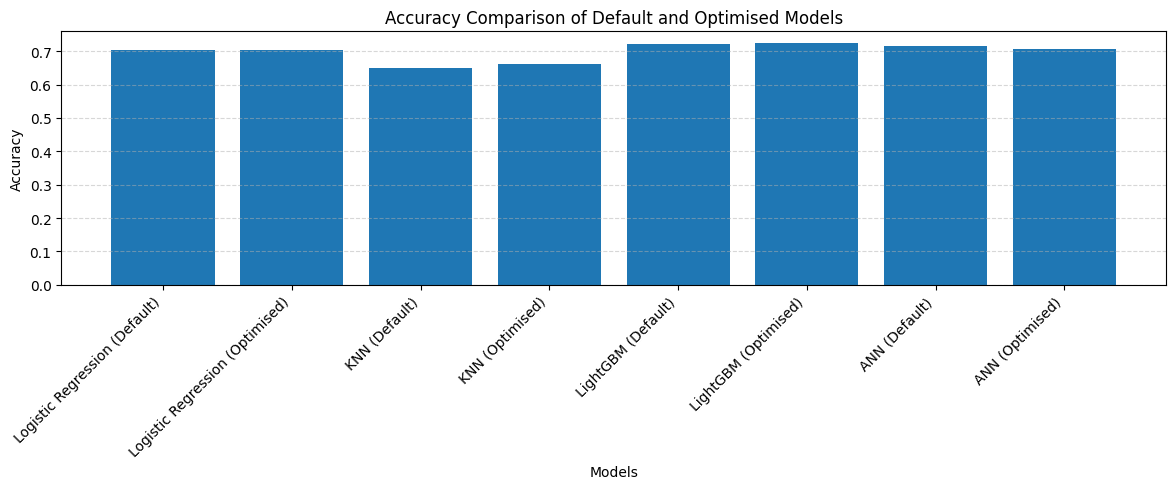

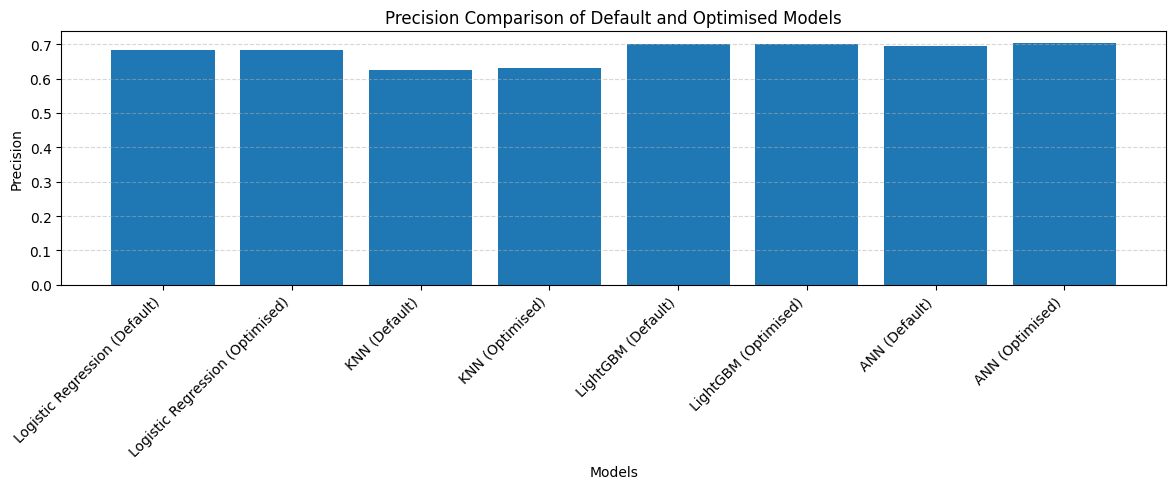

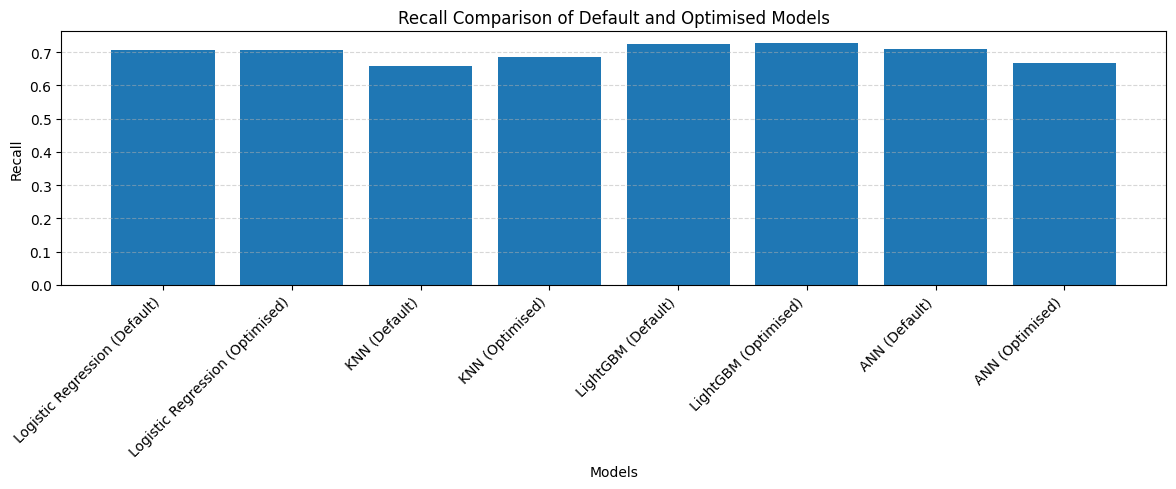

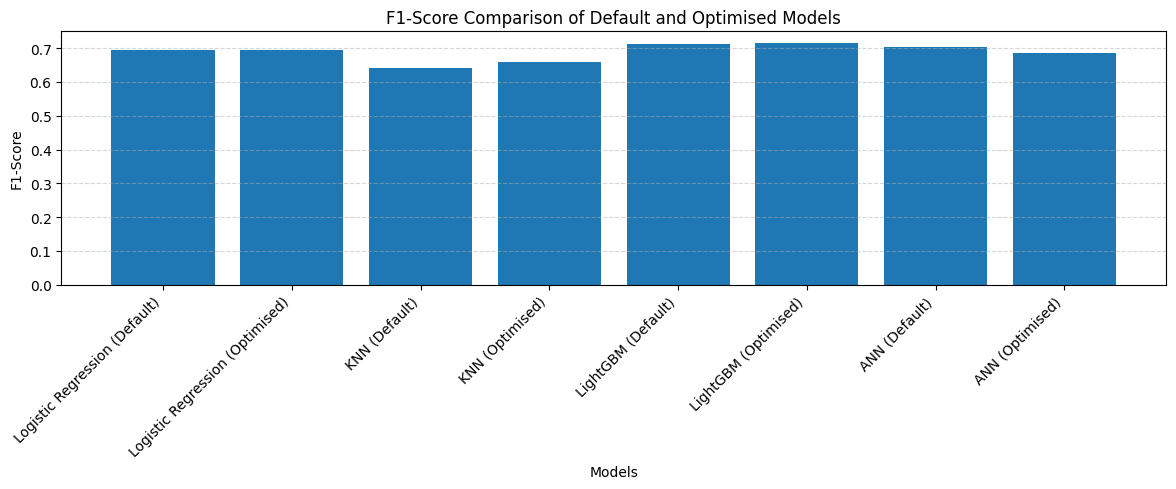

In [28]:
# I imported the required libraries.
import matplotlib.pyplot as plt

# I extracted the model names.
models = combined_models_comparison["Model"]

# I created the Accuracy comparison graph.
plt.figure(figsize=(12,5))

plt.bar(models, combined_models_comparison["Accuracy"])

plt.title("Accuracy Comparison of Default and Optimised Models")

plt.xlabel("Models")

plt.ylabel("Accuracy")

plt.xticks(rotation=45, ha="right")

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()

plt.show()

# I created the Precision comparison graph.
plt.figure(figsize=(12,5))

plt.bar(models, combined_models_comparison["Precision"])

plt.title("Precision Comparison of Default and Optimised Models")

plt.xlabel("Models")

plt.ylabel("Precision")

plt.xticks(rotation=45, ha="right")

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()

plt.show()

# I created the Recall comparison graph.
plt.figure(figsize=(12,5))

plt.bar(models, combined_models_comparison["Recall"])

plt.title("Recall Comparison of Default and Optimised Models")

plt.xlabel("Models")

plt.ylabel("Recall")

plt.xticks(rotation=45, ha="right")

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()

plt.show()

# I created the F1-Score comparison graph.
plt.figure(figsize=(12,5))

plt.bar(models, combined_models_comparison["F1-Score"])

plt.title("F1-Score Comparison of Default and Optimised Models")

plt.xlabel("Models")

plt.ylabel("F1-Score")

plt.xticks(rotation=45, ha="right")

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()

plt.show()

# Visual Analysis

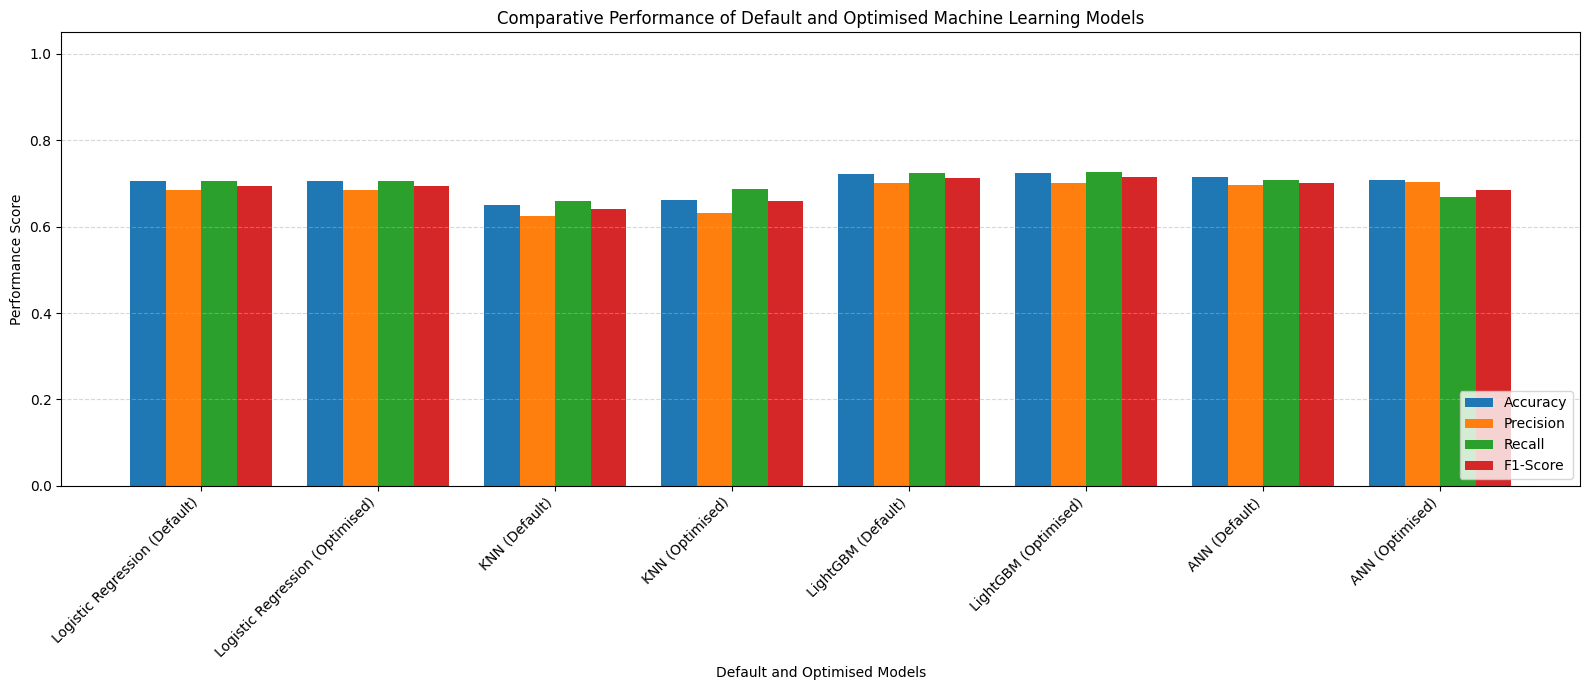

In [29]:
# I imported the required libraries.
import matplotlib.pyplot as plt
import numpy as np

# I extracted the model names.
models = combined_models_comparison["Model"]

# I extracted the evaluation metrics.
accuracy = combined_models_comparison["Accuracy"]
precision = combined_models_comparison["Precision"]
recall = combined_models_comparison["Recall"]
f1_score = combined_models_comparison["F1-Score"]

# I defined the bar positions.
x = np.arange(len(models))

bar_width = 0.20

# I created the combined comparison graph.
plt.figure(figsize=(16,7))

plt.bar(
    x - 1.5 * bar_width,
    accuracy,
    width=bar_width,
    label="Accuracy"
)

plt.bar(
    x - 0.5 * bar_width,
    precision,
    width=bar_width,
    label="Precision"
)

plt.bar(
    x + 0.5 * bar_width,
    recall,
    width=bar_width,
    label="Recall"
)

plt.bar(
    x + 1.5 * bar_width,
    f1_score,
    width=bar_width,
    label="F1-Score"
)

plt.xticks(
    x,
    models,
    rotation=45,
    ha="right"
)

plt.xlabel("Default and Optimised Models")

plt.ylabel("Performance Score")

plt.title("Comparative Performance of Default and Optimised Machine Learning Models")

plt.ylim(0, 1.05)

plt.legend(loc="lower right")

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()

plt.show()

# SHAP Analysis

/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


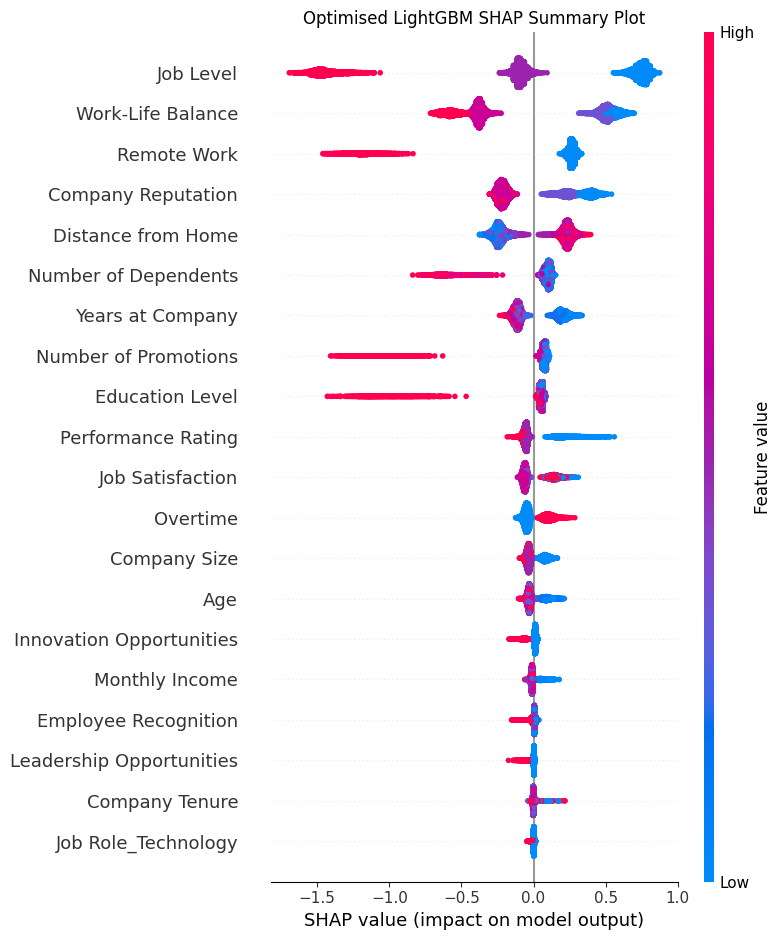

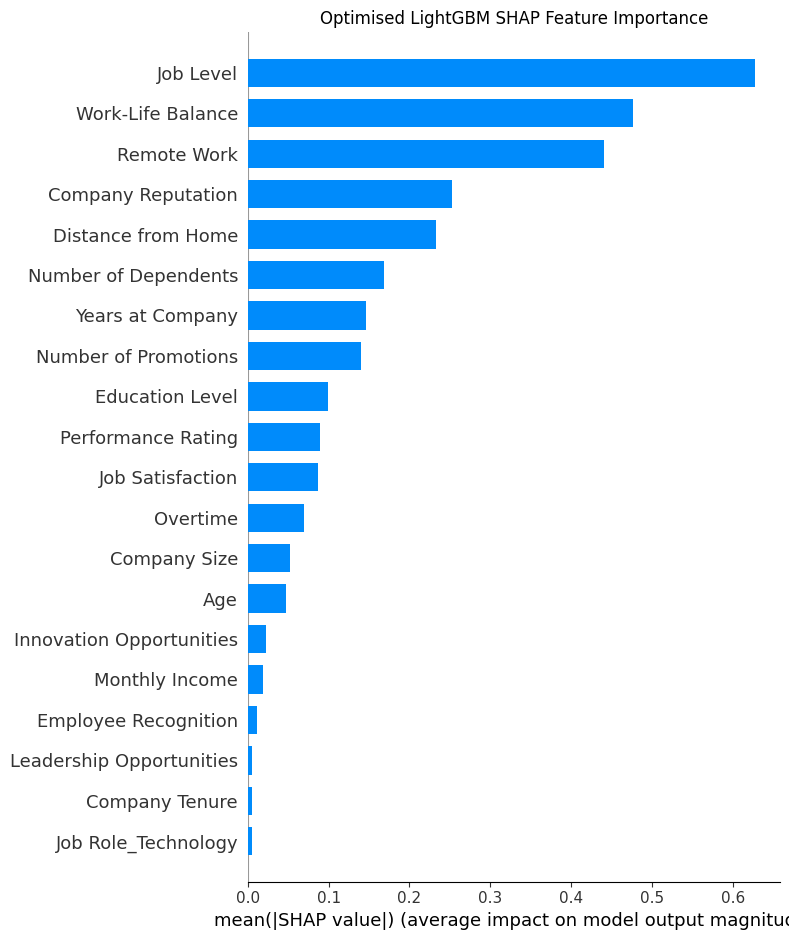

In [30]:
# I imported the required libraries.
import shap
import matplotlib.pyplot as plt

# I initialised the SHAP explainer.
explainer = shap.TreeExplainer(best_lgbm_model)

# I calculated the SHAP values.
shap_values = explainer.shap_values(X_valid)

# I created the SHAP summary plot.
plt.figure(figsize=(10,6))

shap.summary_plot(
    shap_values,
    X_valid,
    feature_names=X_valid.columns,
    show=False
)

plt.title("Optimised LightGBM SHAP Summary Plot")

plt.tight_layout()

plt.show()

# I created the SHAP feature importance plot.
plt.figure(figsize=(10,6))

shap.summary_plot(
    shap_values,
    X_valid,
    feature_names=X_valid.columns,
    plot_type="bar",
    show=False
)

plt.title("Optimised LightGBM SHAP Feature Importance")

plt.tight_layout()

plt.show()

/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


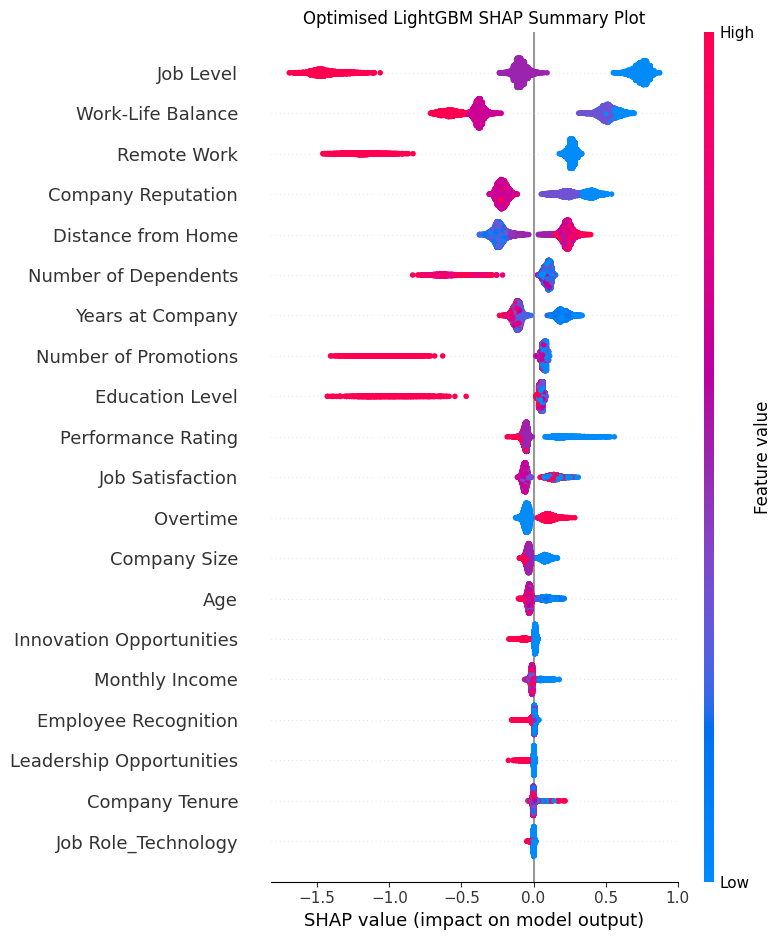

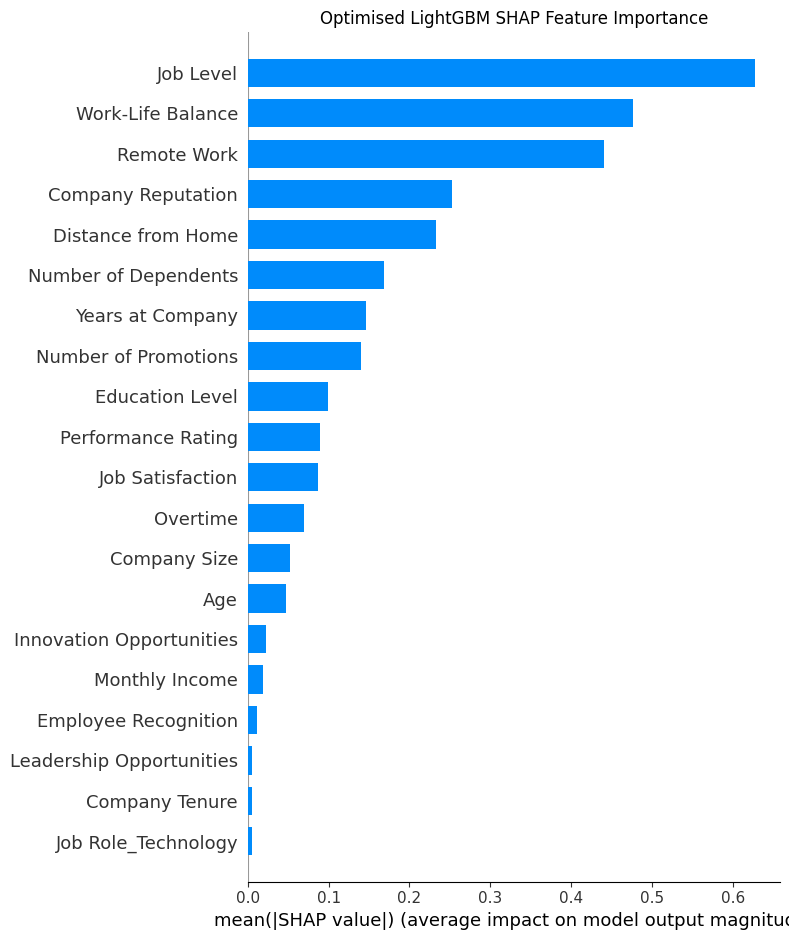


Top 10 Most Important Features
                 Feature  Mean |SHAP Value|
11             Job Level           0.627194
3      Work-Life Balance           0.476711
14           Remote Work           0.440864
17    Company Reputation           0.252529
8     Distance from Home           0.232833
10  Number of Dependents           0.169029
1       Years at Company           0.146327
6   Number of Promotions           0.140149
9        Education Level           0.099247
5     Performance Rating           0.088725


<Figure size 800x600 with 0 Axes>

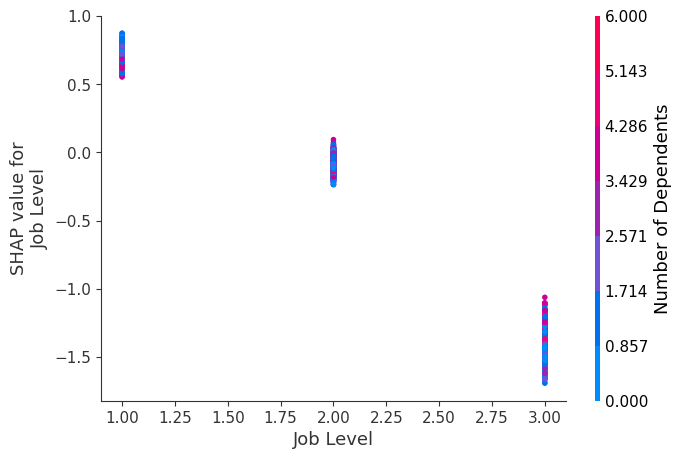

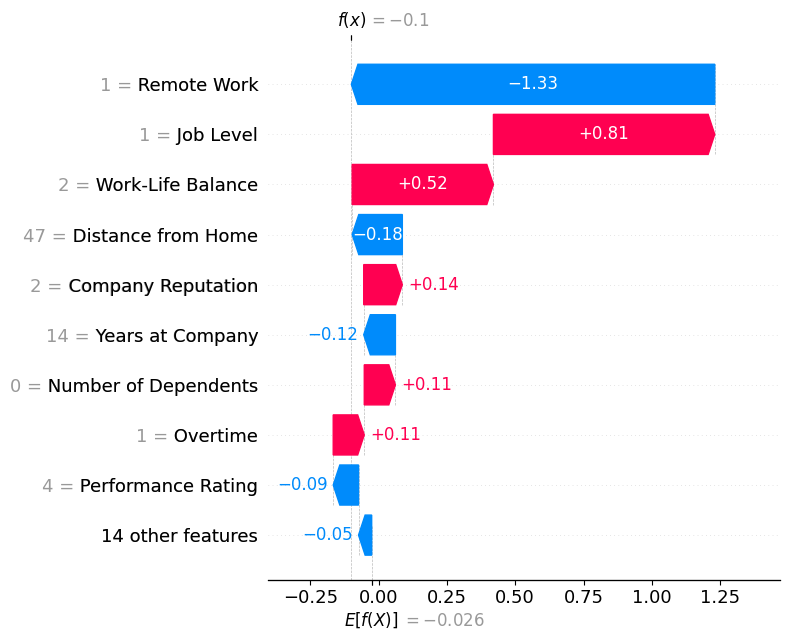

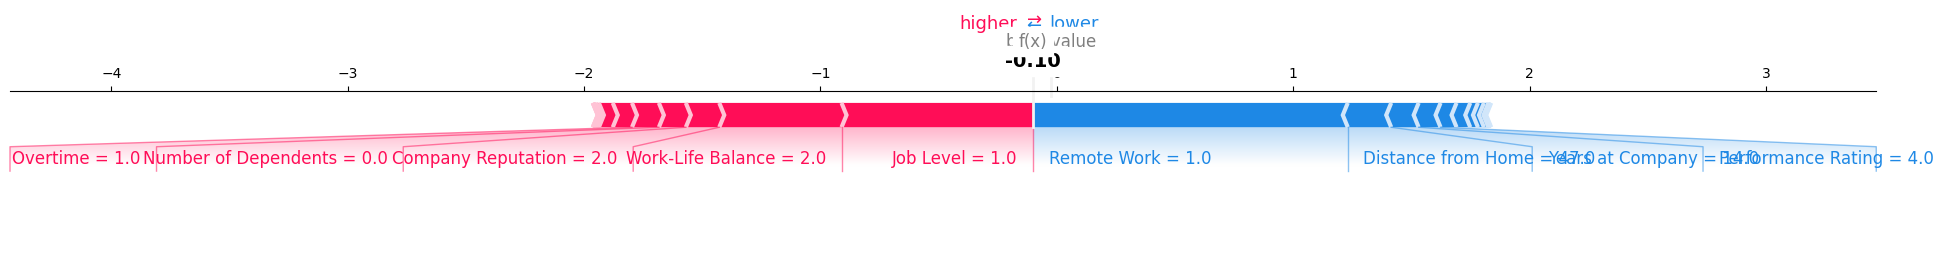

In [31]:
# I imported the required libraries.
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# I initialised the SHAP explainer.
explainer = shap.TreeExplainer(best_lgbm_model)

# I calculated the SHAP values.
shap_values = explainer.shap_values(X_valid)

# I handled binary classification SHAP output.
if isinstance(shap_values, list):
    shap_values = shap_values[1]

# I displayed the SHAP summary plot.
plt.figure(figsize=(10,6))
shap.summary_plot(
    shap_values,
    X_valid,
    feature_names=X_valid.columns,
    show=False
)
plt.title("Optimised LightGBM SHAP Summary Plot")
plt.tight_layout()
plt.show()

# I displayed the SHAP feature importance plot.
plt.figure(figsize=(10,6))
shap.summary_plot(
    shap_values,
    X_valid,
    feature_names=X_valid.columns,
    plot_type="bar",
    show=False
)
plt.title("Optimised LightGBM SHAP Feature Importance")
plt.tight_layout()
plt.show()

# I calculated the mean absolute SHAP values.
feature_importance = pd.DataFrame({
    "Feature": X_valid.columns,
    "Mean |SHAP Value|": np.abs(shap_values).mean(axis=0)
})

feature_importance = feature_importance.sort_values(
    by="Mean |SHAP Value|",
    ascending=False
)

print("\nTop 10 Most Important Features")
print(feature_importance.head(10))

# I displayed the dependence plot.
top_feature = feature_importance.iloc[0]["Feature"]

plt.figure(figsize=(8,6))
shap.dependence_plot(
    top_feature,
    shap_values,
    X_valid,
    interaction_index="auto"
)
plt.show()

# I displayed the waterfall plot.
sample_index = 0

waterfall_values = shap.Explanation(
    values=shap_values[sample_index],
    base_values=explainer.expected_value,
    data=X_valid.iloc[sample_index],
    feature_names=X_valid.columns
)

plt.figure(figsize=(8,6))
shap.plots.waterfall(
    waterfall_values,
    max_display=10,
    show=False
)
plt.tight_layout()
plt.show()

# I displayed the force plot.
force_plot = shap.force_plot(
    explainer.expected_value,
    shap_values[sample_index],
    X_valid.iloc[sample_index],
    matplotlib=True,
    show=False
)

plt.tight_layout()
plt.show()